In [101]:
import os, glob, re, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import torch

RESULTS_DIR   = '/workspace/PCFG/results'
HISTORIES_DIR = f'{RESULTS_DIR}/histories'
SUMMARY_PATH  = f'{RESULTS_DIR}/finetune_experiment_summary.json'

with open(SUMMARY_PATH) as f:
    summary = json.load(f)

CORRS = sorted([float(k.split('_')[1]) for k in summary])
CONCS = sorted([float(k.split('_')[1]) for k in summary[f'corr_{CORRS[0]:.2f}']])
print('Correlations:', CORRS)
print('Concentrations:', CONCS)

Correlations: [0.25, 1.0]
Concentrations: [0.3, 1.0]


## Load all history files

In [102]:
histories = {}
for path in sorted(glob.glob(f'{HISTORIES_DIR}/*_history.pth')):
    name = os.path.basename(path).replace('_history.pth', '')
    histories[name] = torch.load(path, map_location='cpu', weights_only=False)

print(f'Loaded {len(histories)} history files')
print('Sample keys:', list(histories.keys())[:4])

Loaded 12 history files
Sample keys: ['finetune_corr_0.00_conc_0.10', 'finetune_corr_0.25_conc_0.30', 'finetune_corr_0.25_conc_0.50', 'finetune_corr_0.25_conc_1.00']


## Colour / alpha helpers

In [103]:
# One colour per correlation value
CORR_PALETTE = {
    0.00: '#e74c3c',   # red
    0.25: '#e67e22',   # orange
    0.50: '#f1c40f',   # yellow
    0.75: '#2ecc71',   # green
    1.00: '#2980b9',   # blue
}

# Alpha proportional to concentration (min 0.25 so curves are always visible)
CONC_ALPHA = {c: 0.25 + 0.75 * (c - min(CONCS)) / (max(CONCS) - min(CONCS))
              for c in CONCS}

VAL_SPLITS = ['count_a_corr', 'count_a_uncorr', 'count_b_corr', 'count_b_uncorr',
              'all_other_corr', 'all_other_uncorr']
SPLIT_LABELS = {
    'count_a_corr':     'Count-A (correlated)',
    'count_a_uncorr':   'Count-A (uncorrelated)',
    'count_b_corr':     'Count-B (correlated)',
    'count_b_uncorr':   'Count-B (uncorrelated)',
    'all_other_corr':   'All other (correlated)',
    'all_other_uncorr': 'All other (uncorrelated)',
}

# Weighted-average helpers: maps a weighted key to its (corr_split, uncorr_split) pair
WEIGHTED_SPLITS = {
    'count_a_avg':   ('count_a_corr',   'count_a_uncorr'),
    'count_b_avg':   ('count_b_corr',   'count_b_uncorr'),
    'all_other_avg': ('all_other_corr', 'all_other_uncorr'),
}


## Loss curves — all runs on one plot per val-split

Colour = correlation, alpha = concentration (darker = more concentrated).

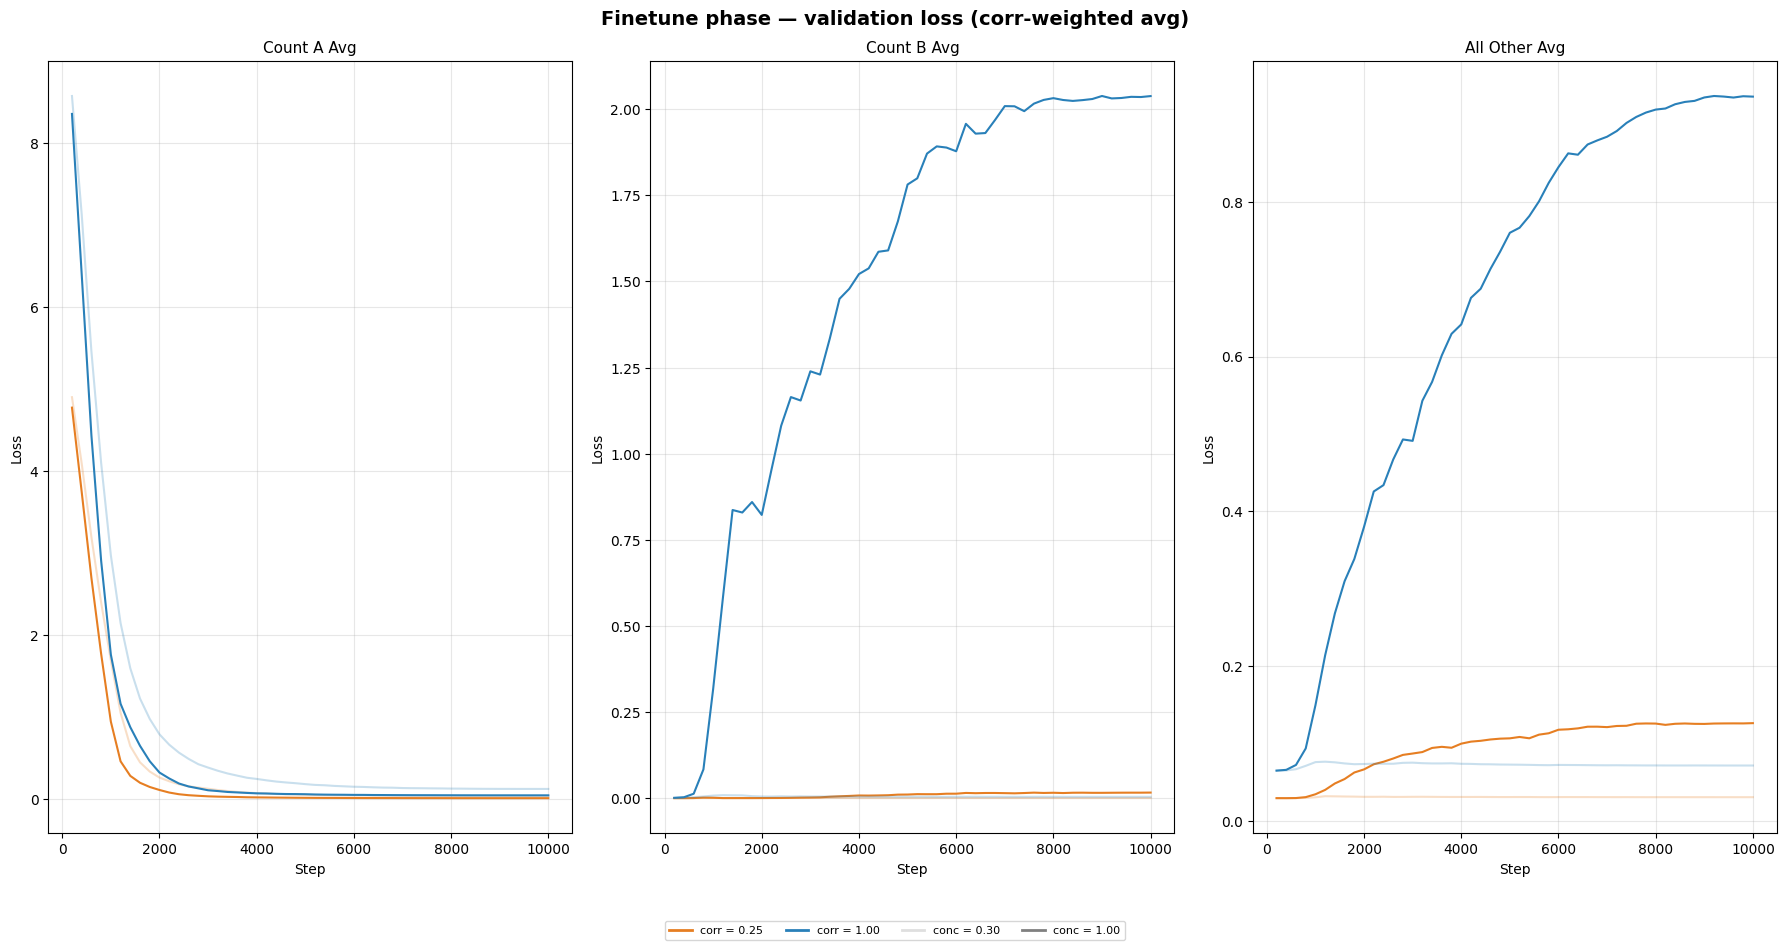

In [104]:
def _get_vals(hist, split, metric, corr, use_weighted):
    """Get values from history, optionally using corr-weighted average."""
    if use_weighted and split in WEIGHTED_SPLITS:
        corr_split, uncorr_split = WEIGHTED_SPLITS[split]
        if corr_split in hist['val']:
            return corr * np.array(hist['val'][corr_split][metric]) + \
                   (1 - corr) * np.array(hist['val'][uncorr_split][metric])
        # fallback: try the split directly
        if split in hist['val']:
            return np.array(hist['val'][split][metric])
        return None
    if split in hist['val']:
        return np.array(hist['val'][split][metric])
    return None


def plot_loss_curves(phase='finetune', metric='loss', figsize=(18, 9), use_weighted=False):
    """Plot all runs for a given training phase.
    phase        : 'finetune' or 'reverse'
    metric       : 'loss' or 'answer_acc'
    use_weighted : if True, show 3 weighted-avg panels instead of raw splits
    """
    splits = list(WEIGHTED_SPLITS.keys()) if use_weighted else VAL_SPLITS
    labels = {k: k.replace('_', ' ').title() for k in splits}
    if not use_weighted:
        labels = SPLIT_LABELS

    fig, axes = plt.subplots(1, len(splits), figsize=figsize, sharey=False)
    if len(splits) == 1:
        axes = [axes]
    wt_tag = ' (corr-weighted avg)' if use_weighted else ''
    fig.suptitle(f'{phase.capitalize()} phase — validation {metric}{wt_tag}',
                 fontsize=14, fontweight='bold')

    for ax, split in zip(axes, splits):
        for corr in CORRS:
            color = CORR_PALETTE[corr]
            for conc in CONCS:
                key = f'{phase}_corr_{corr:.2f}_conc_{conc:.2f}'
                if key not in histories:
                    continue
                h = histories[key]
                vals = _get_vals(h, split, metric, corr, use_weighted)
                if vals is None:
                    continue
                steps = h['steps']
                ax.plot(steps, vals,
                        color=color,
                        alpha=CONC_ALPHA[conc],
                        linewidth=1.5,
                        label=f'corr={corr:.2f} conc={conc:.2f}')

        ax.set_title(labels.get(split, split), fontsize=11)
        ax.set_xlabel('Step')
        ax.set_ylabel(metric.replace('_', ' ').capitalize())
        ax.grid(True, alpha=0.3)

    corr_handles = [
        plt.Line2D([0], [0], color=CORR_PALETTE[c], linewidth=2,
                   label=f'corr = {c:.2f}')
        for c in CORRS
    ]
    conc_handles = [
        plt.Line2D([0], [0], color='grey', alpha=CONC_ALPHA[c], linewidth=2,
                   label=f'conc = {c:.2f}')
        for c in CONCS
    ]
    fig.legend(handles=corr_handles + conc_handles,
               loc='lower center', ncol=len(CORRS) + len(CONCS),
               fontsize=8, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    plt.show()


plot_loss_curves(phase='finetune', metric='loss', use_weighted=True)


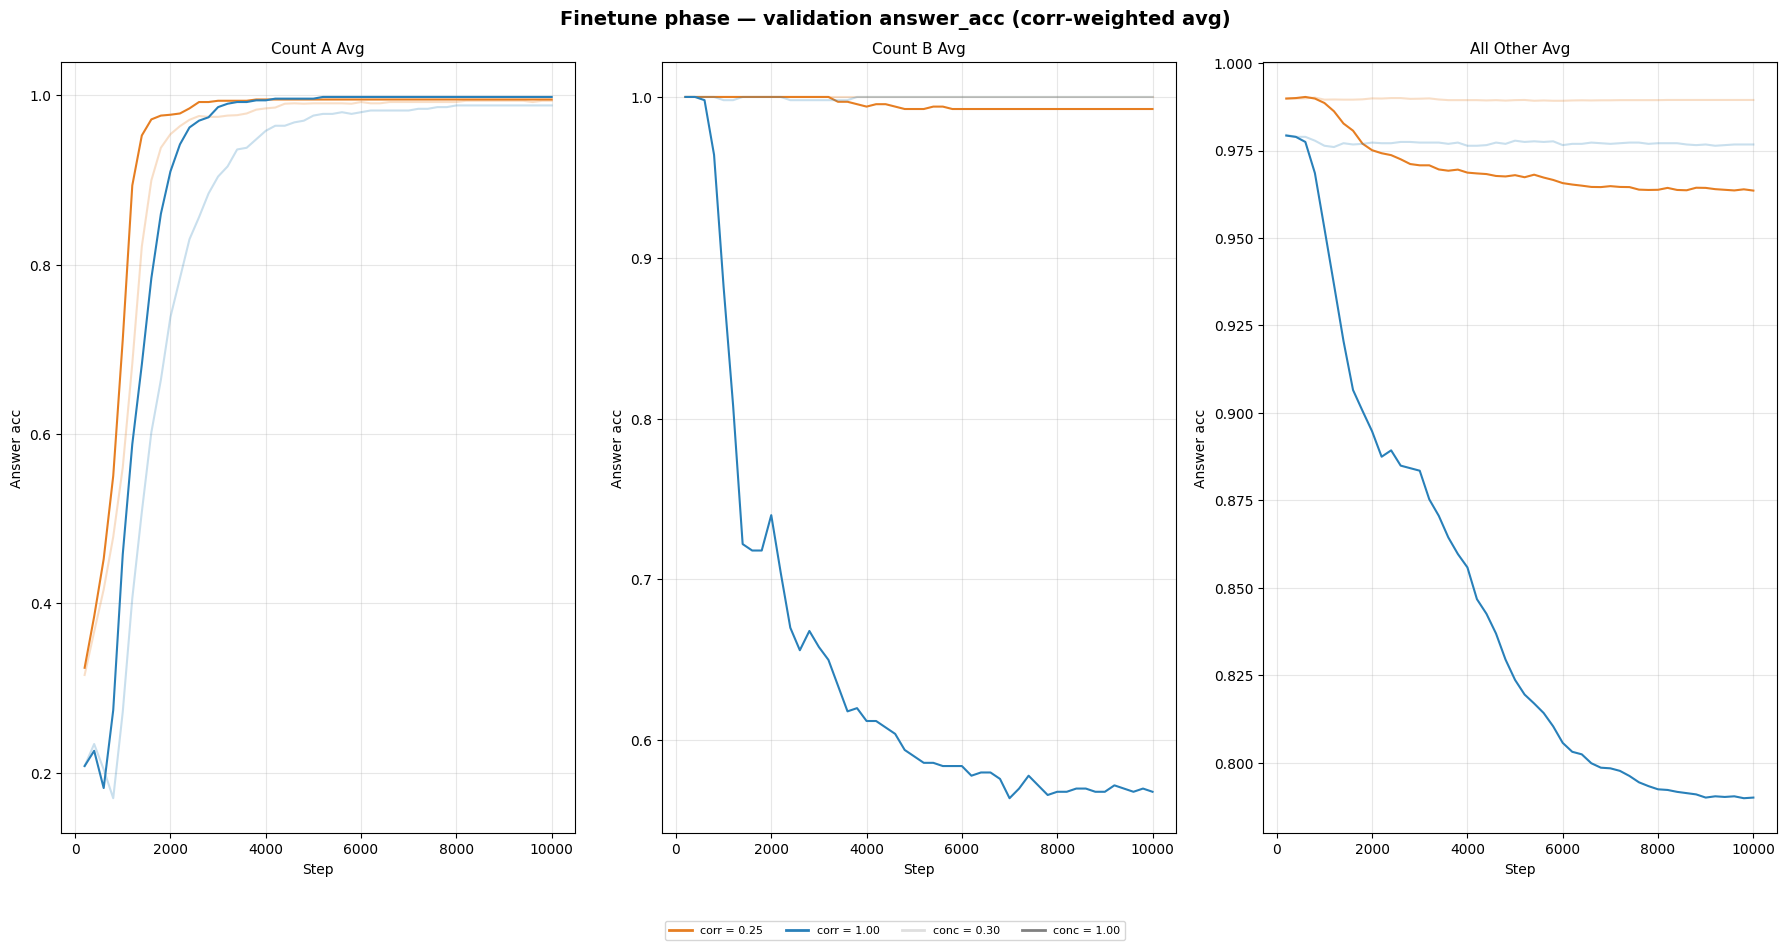

In [105]:
plot_loss_curves(phase='finetune', metric='answer_acc', use_weighted=True)

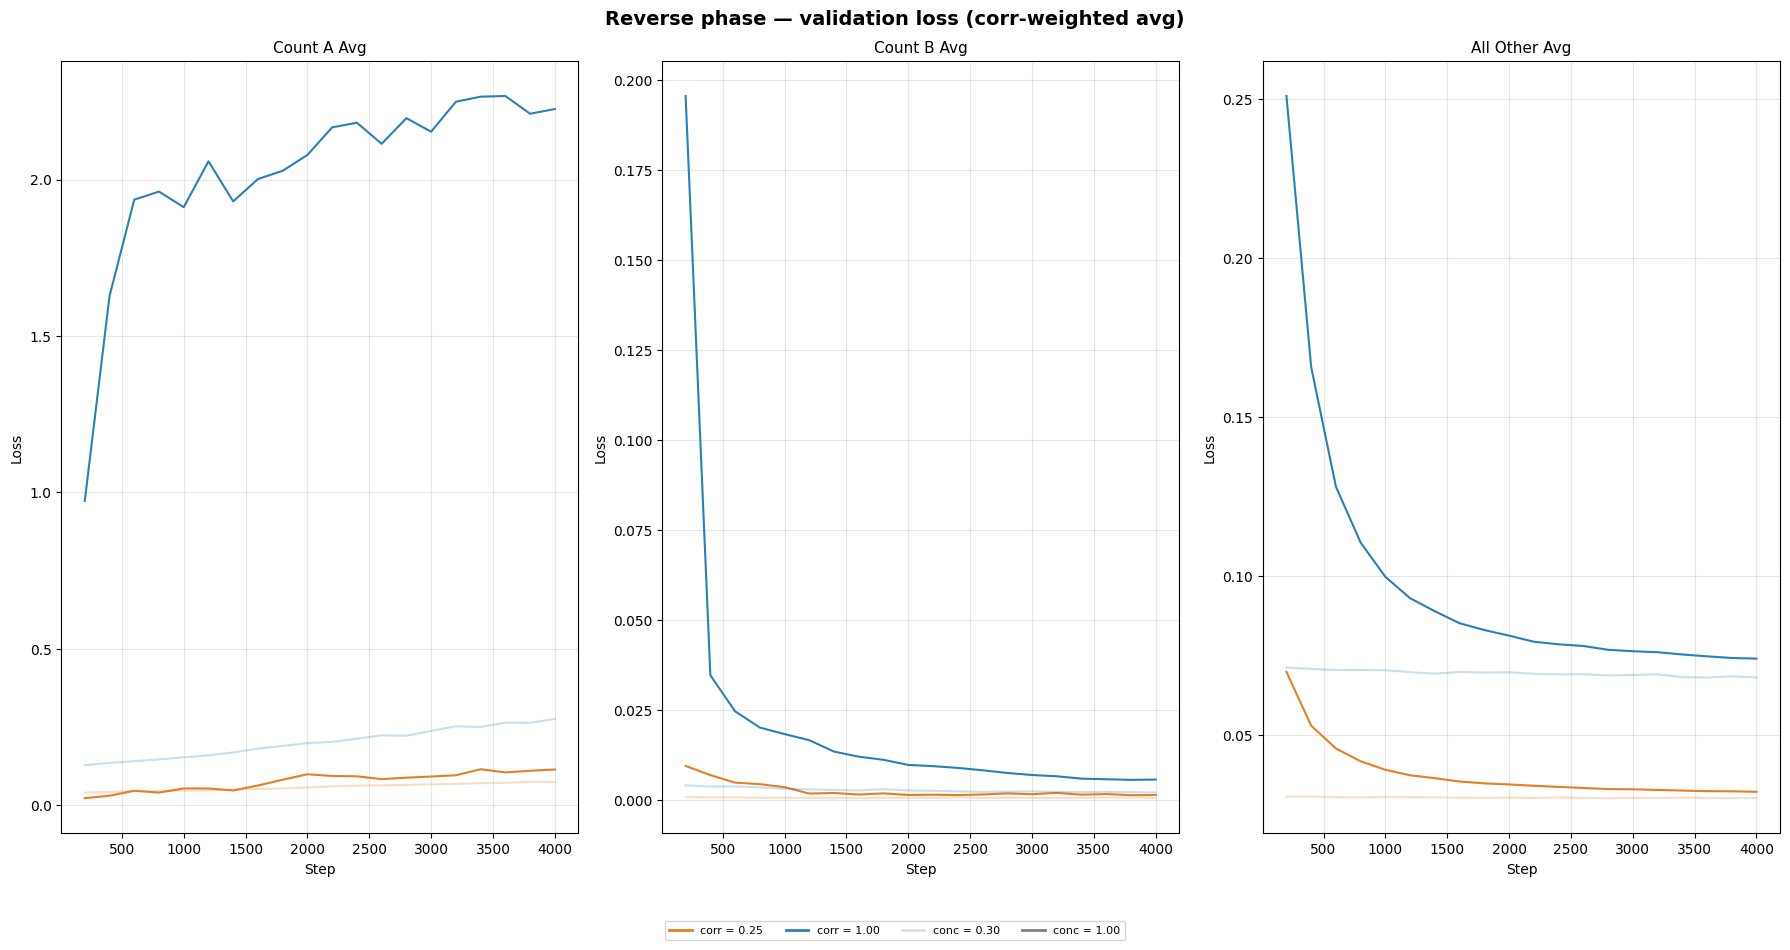

In [106]:
plot_loss_curves(phase='reverse', metric='loss', use_weighted=True)

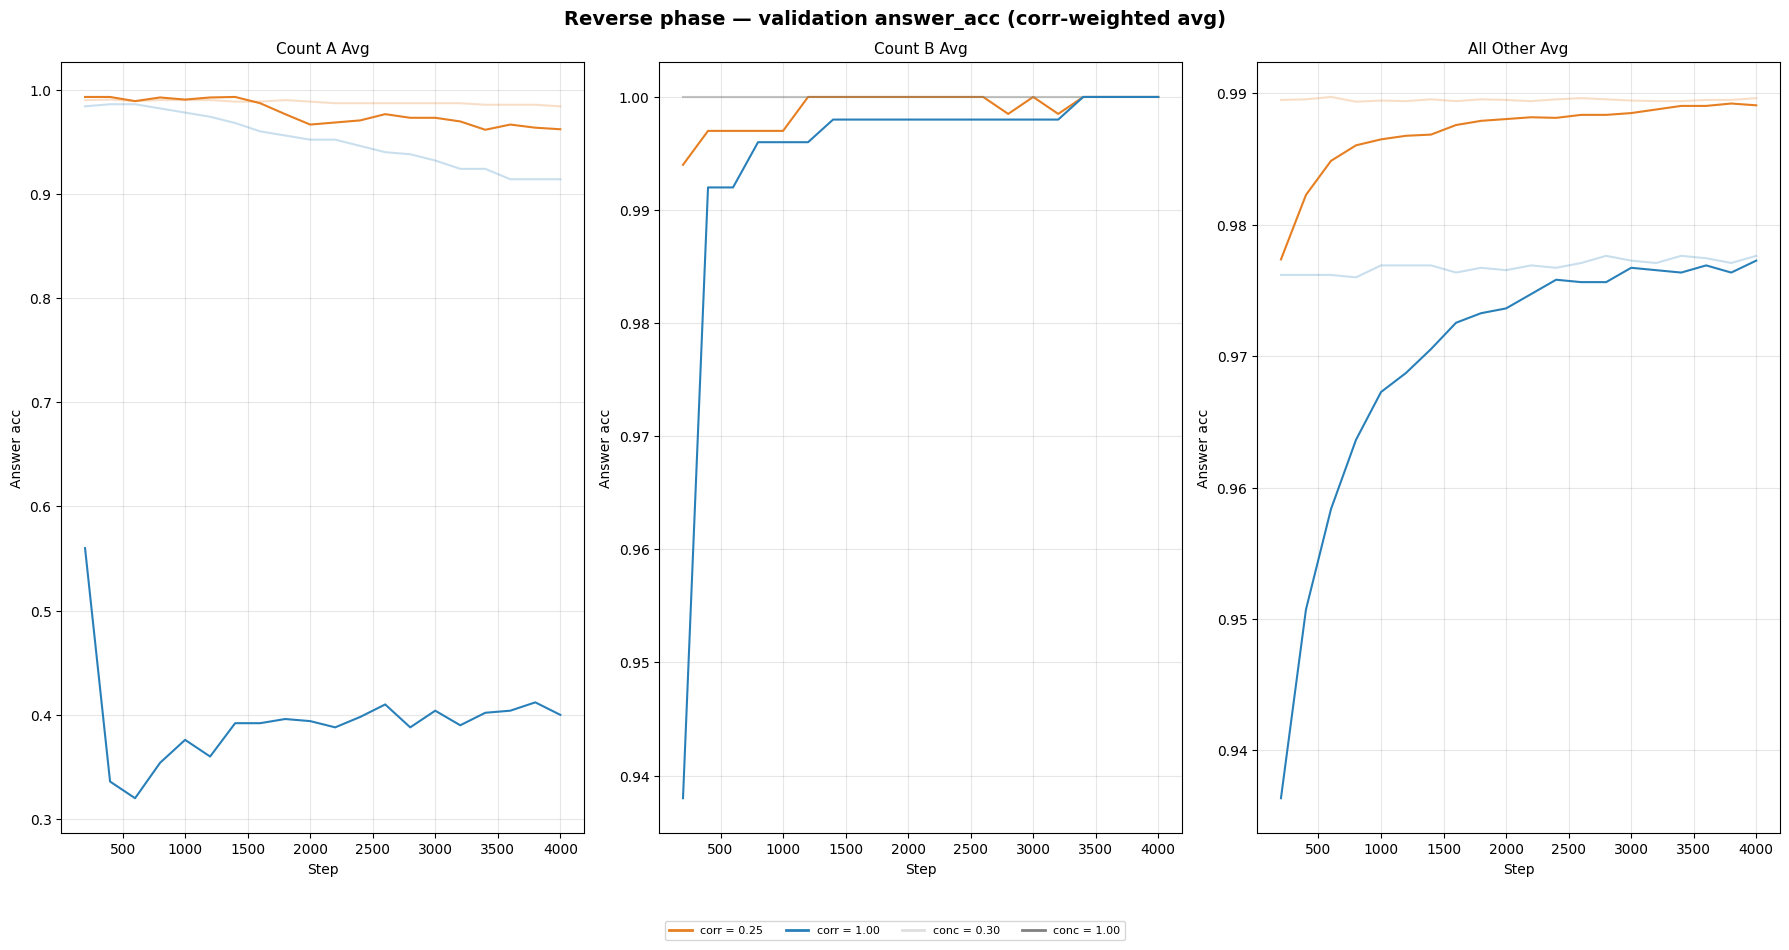

In [107]:
plot_loss_curves(phase='reverse', metric='answer_acc', use_weighted=True)


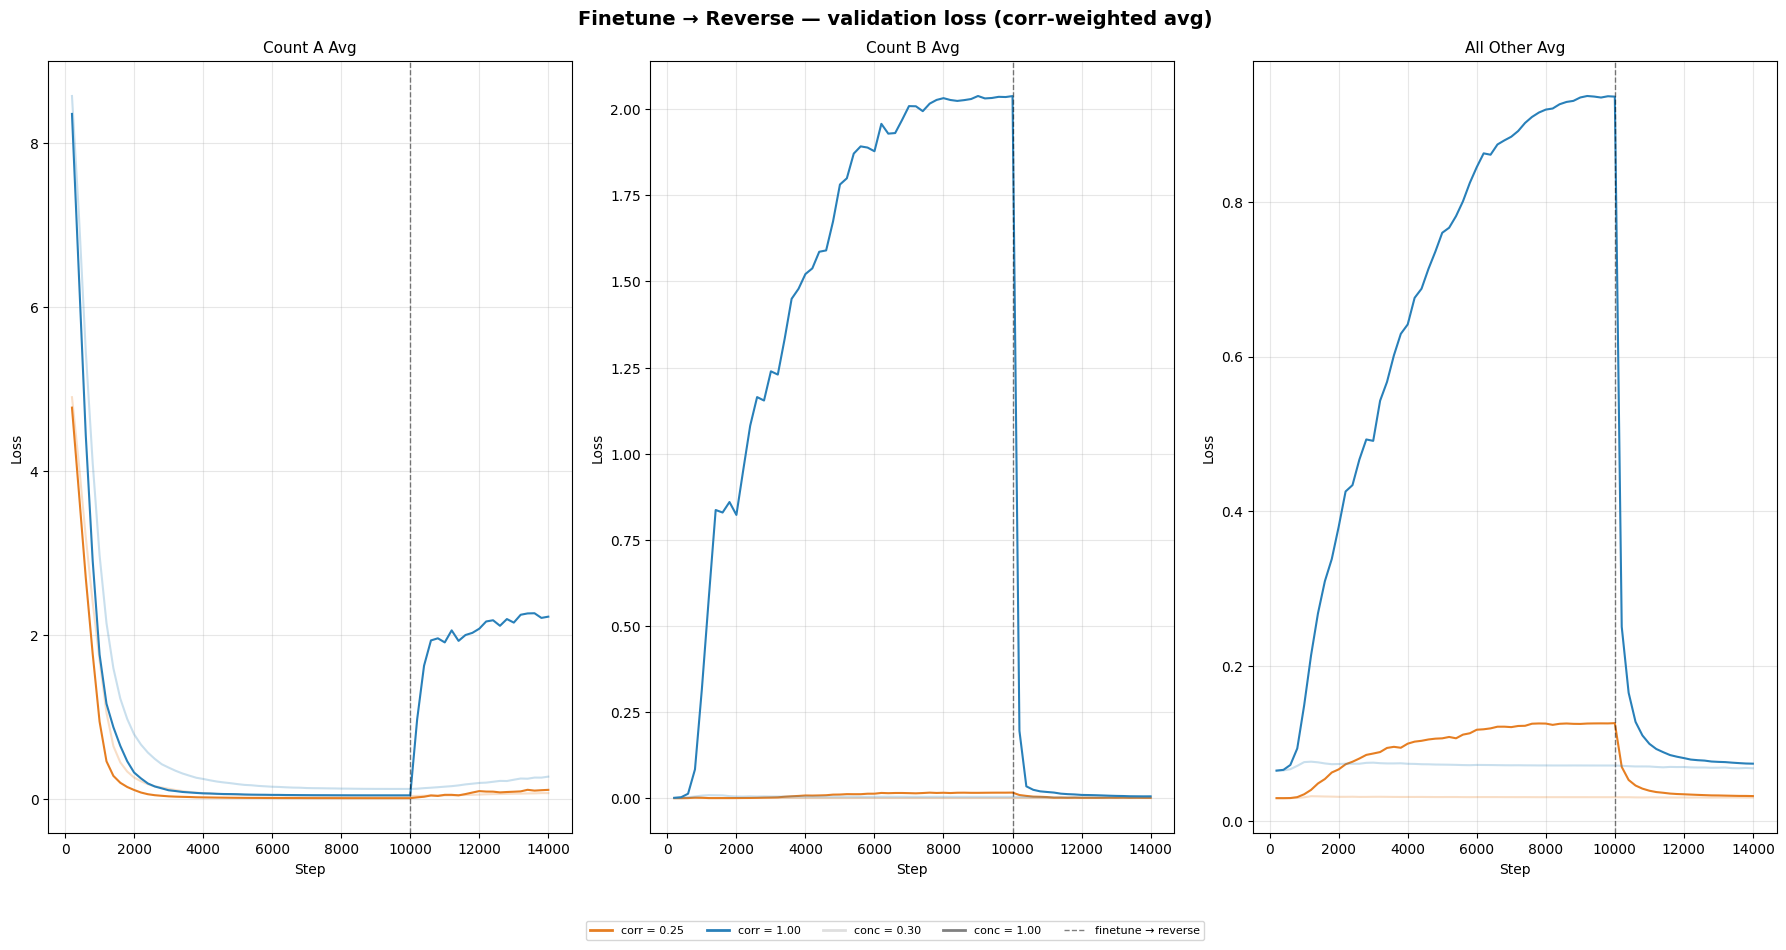

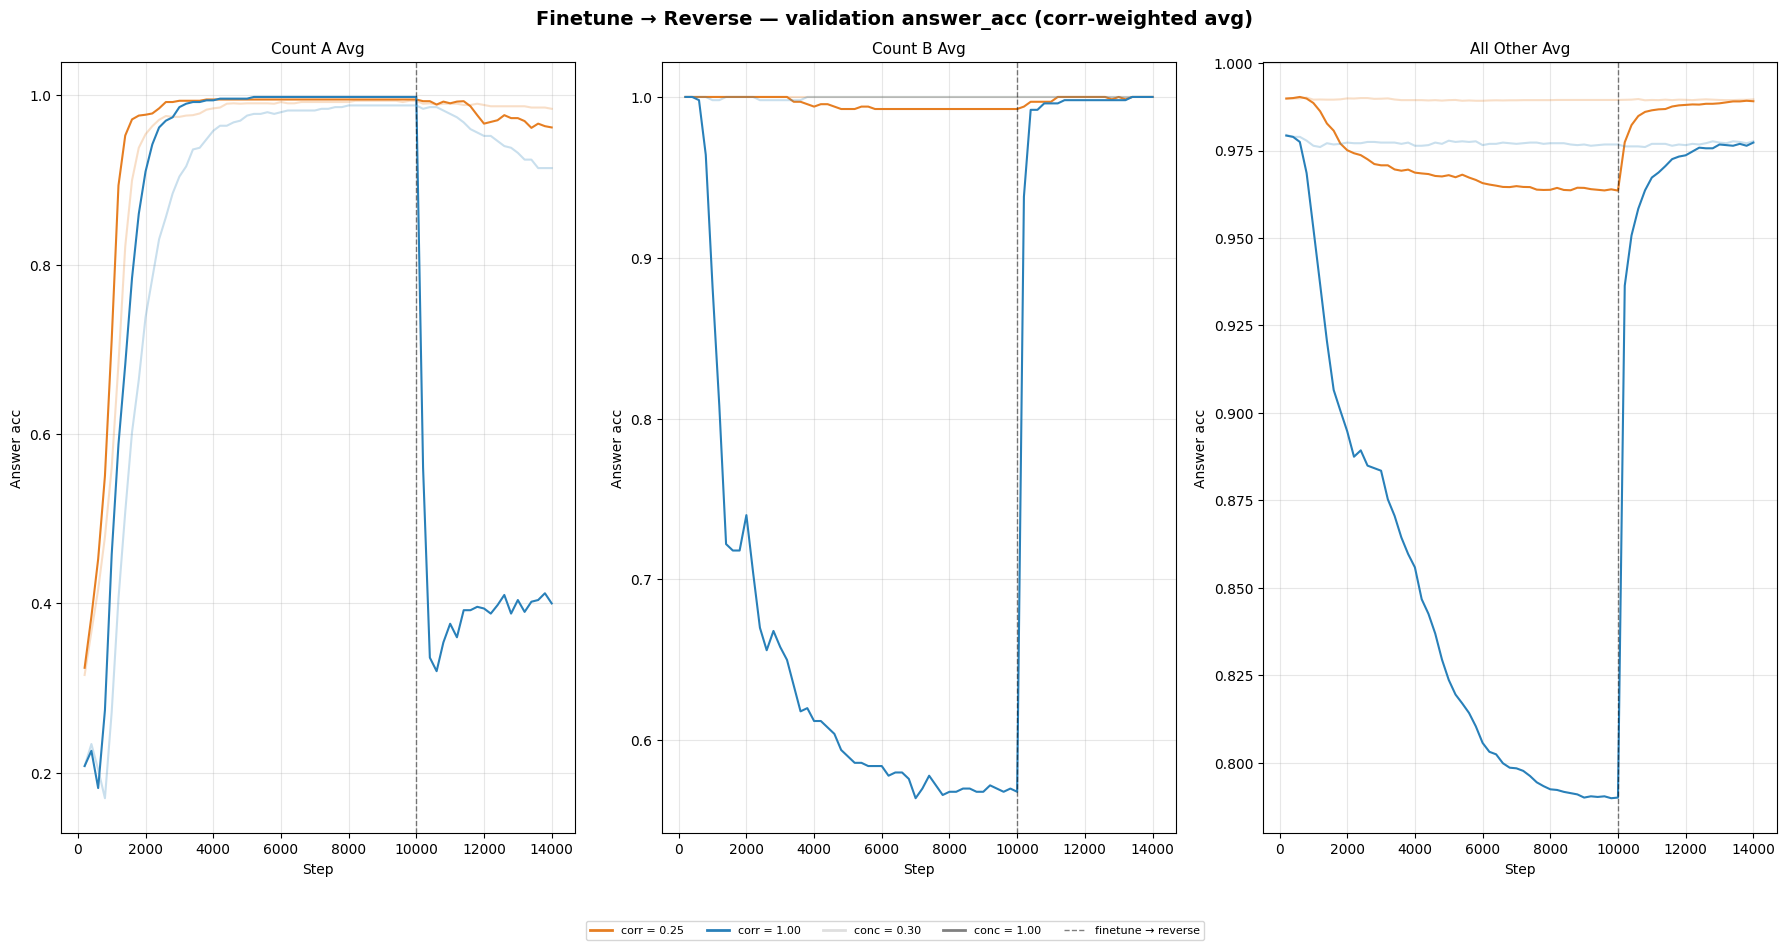

In [108]:
def plot_combined_loss_curves(metric='loss', figsize=(18, 9), use_weighted=False):
    """Plot finetune + reverse phases appended, with a vertical line at the boundary.
    use_weighted : if True, show 3 weighted-avg panels instead of raw splits
    """
    splits = list(WEIGHTED_SPLITS.keys()) if use_weighted else VAL_SPLITS
    labels = {k: k.replace('_', ' ').title() for k in splits}
    if not use_weighted:
        labels = SPLIT_LABELS

    fig, axes = plt.subplots(1, len(splits), figsize=figsize, sharey=False)
    if len(splits) == 1:
        axes = [axes]
    wt_tag = ' (corr-weighted avg)' if use_weighted else ''
    fig.suptitle(f'Finetune → Reverse — validation {metric}{wt_tag}',
                 fontsize=14, fontweight='bold')

    boundary_step = None

    for ax, split in zip(axes, splits):
        for corr in CORRS:
            color = CORR_PALETTE[corr]
            for conc in CONCS:
                ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
                rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'
                if ft_key not in histories or rv_key not in histories:
                    continue

                ft_h = histories[ft_key]
                rv_h = histories[rv_key]

                ft_vals = _get_vals(ft_h, split, metric, corr, use_weighted)
                rv_vals = _get_vals(rv_h, split, metric, corr, use_weighted)
                if ft_vals is None or rv_vals is None:
                    continue

                ft_steps = ft_h['steps']
                ft_last = ft_steps[-1]
                rv_steps = [ft_last + s for s in rv_h['steps']]

                combined_steps = list(ft_steps) + list(rv_steps)
                combined_vals  = list(ft_vals)  + list(rv_vals)

                if boundary_step is None:
                    boundary_step = ft_last

                ax.plot(combined_steps, combined_vals,
                        color=color,
                        alpha=CONC_ALPHA[conc],
                        linewidth=1.5)

        ax.axvline(boundary_step, color='black', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_title(labels.get(split, split), fontsize=11)
        ax.set_xlabel('Step')
        ax.set_ylabel(metric.replace('_', ' ').capitalize())
        ax.grid(True, alpha=0.3)

    corr_handles = [
        plt.Line2D([0], [0], color=CORR_PALETTE[c], linewidth=2,
                   label=f'corr = {c:.2f}')
        for c in CORRS
    ]
    conc_handles = [
        plt.Line2D([0], [0], color='grey', alpha=CONC_ALPHA[c], linewidth=2,
                   label=f'conc = {c:.2f}')
        for c in CONCS
    ]
    phase_handle = [plt.Line2D([0], [0], color='black', linestyle='--',
                               alpha=0.5, linewidth=1, label='finetune → reverse')]

    fig.legend(handles=corr_handles + conc_handles + phase_handle,
               loc='lower center', ncol=len(CORRS) + len(CONCS) + 1,
               fontsize=8, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    plt.show()


plot_combined_loss_curves(metric='loss', use_weighted=True)
plot_combined_loss_curves(metric='answer_acc', use_weighted=True)


## Flatten summary into a DataFrame

In [76]:
rows = []
for corr_key, corr_val in summary.items():
    corr = float(corr_key.split('_')[1])
    for conc_key, conc_val in corr_val.items():
        conc = float(conc_key.split('_')[1])
        for phase_key, metrics in conc_val.items():
            row = dict(corr=corr, conc=conc, phase=phase_key)
            row.update(metrics)
            rows.append(row)

df = pd.DataFrame(rows)

# Forgetting = drop from perfect (1.0) to observed accuracy
df['forget_count_b']    = 1.0 - df['count_b_acc']
df['forget_other']      = 1.0 - df['all_other_avg_acc']
df['forget_count_a_corr']   = 1.0 - df['count_a_corr_acc']
df['forget_count_a_uncorr'] = 1.0 - df['count_a_uncorr_acc']

print(df.shape)
df.head()

KeyError: 'count_b_acc'

## Heatmaps — forgetting after finetuning

Rows = correlation, columns = concentration.  
Values = **1 − accuracy** (i.e. fraction forgotten compared to a perfect baseline).

KeyError: 'forget_count_b'

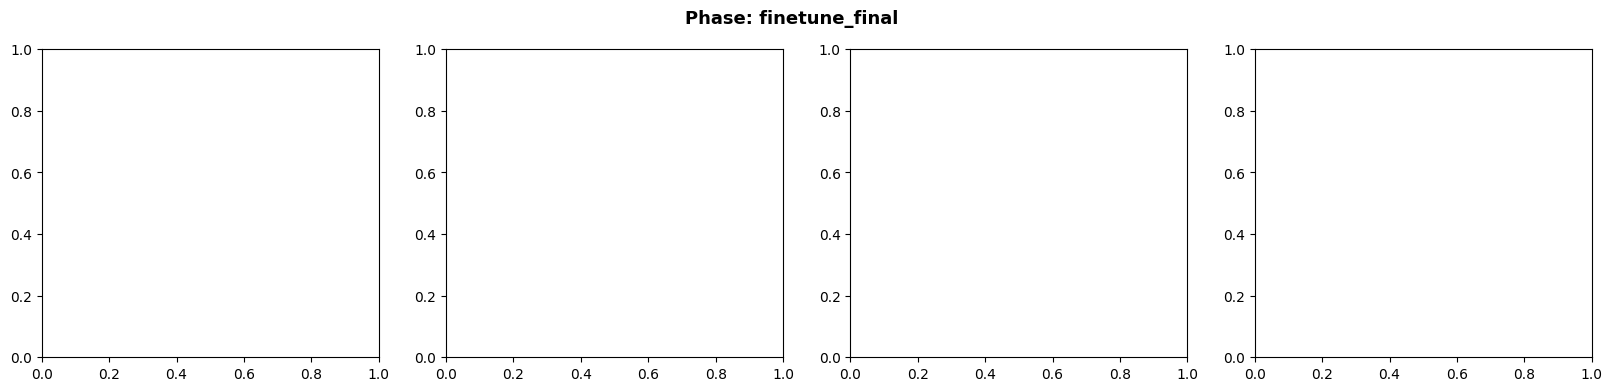

In [77]:
def make_heatmap_grid(phase, metrics, titles, cmaps=None, figsize=None,
                      fmt='.3f', vmin=None, vmax=None):
    """Plot a row of heatmaps (one per metric) for a given phase."""
    n = len(metrics)
    figsize = figsize or (5 * n, 4)
    cmaps   = cmaps   or ['YlOrRd'] * n

    sub = df[df['phase'] == phase]

    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    fig.suptitle(f'Phase: {phase}', fontsize=13, fontweight='bold')

    for ax, metric, title, cmap in zip(axes, metrics, titles, cmaps):
        pivot = sub.pivot(index='corr', columns='conc', values=metric)
        pivot.index   = [f'{v:.2f}' for v in pivot.index]
        pivot.columns = [f'{v:.2f}' for v in pivot.columns]

        vm = vmax if vmax is not None else pivot.values.max()
        vn = vmin if vmin is not None else 0.0

        sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt=fmt,
                    vmin=vn, vmax=vm, linewidths=0.5, linecolor='white',
                    cbar_kws={'shrink': 0.8})
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Concentration')
        ax.set_ylabel('Correlation')

    plt.tight_layout()
    plt.show()


# ---- Forgetting heatmaps (finetune phase) ----
make_heatmap_grid(
    phase='finetune_final',
    metrics=['forget_count_b', 'forget_other',
             'forget_count_a_corr', 'forget_count_a_uncorr'],
    titles=['Forgetting: Count-B', 'Forgetting: Other tasks (avg)',
            'Forgetting: Count-A corr', 'Forgetting: Count-A uncorr'],
    cmaps=['YlOrRd', 'YlOrRd', 'Blues', 'Blues'],
    figsize=(20, 4),
)

KeyError: 'forget_count_b'

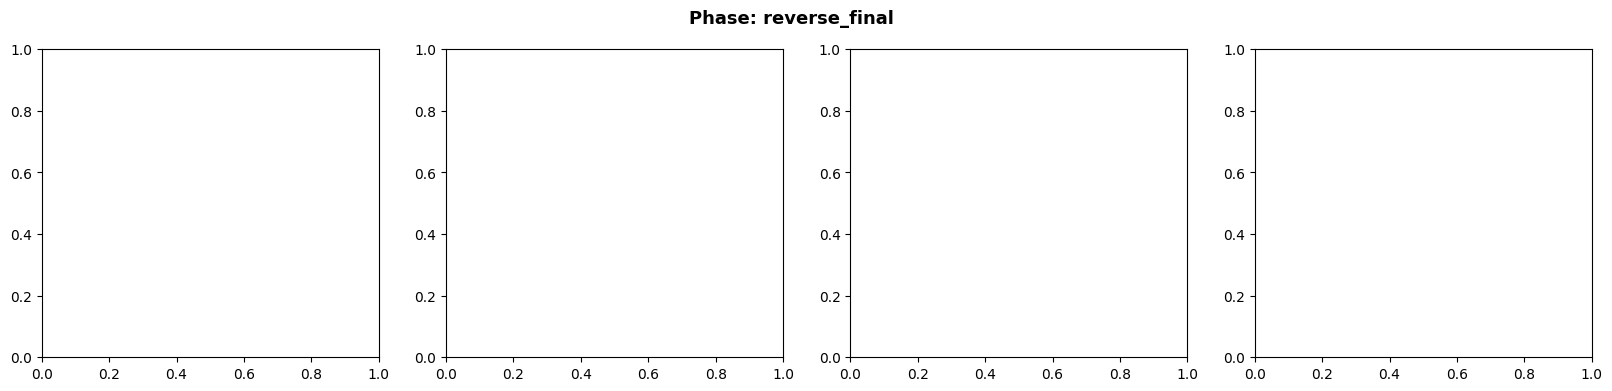

In [78]:
# ---- Same for reverse phase ----
make_heatmap_grid(
    phase='reverse_final',
    metrics=['forget_count_b', 'forget_other',
             'forget_count_a_corr', 'forget_count_a_uncorr'],
    titles=['Forgetting: Count-B', 'Forgetting: Other tasks (avg)',
            'Forgetting: Count-A corr', 'Forgetting: Count-A uncorr'],
    cmaps=['YlOrRd', 'YlOrRd', 'Blues', 'Blues'],
    figsize=(20, 4),
)

## Heatmaps — raw accuracy

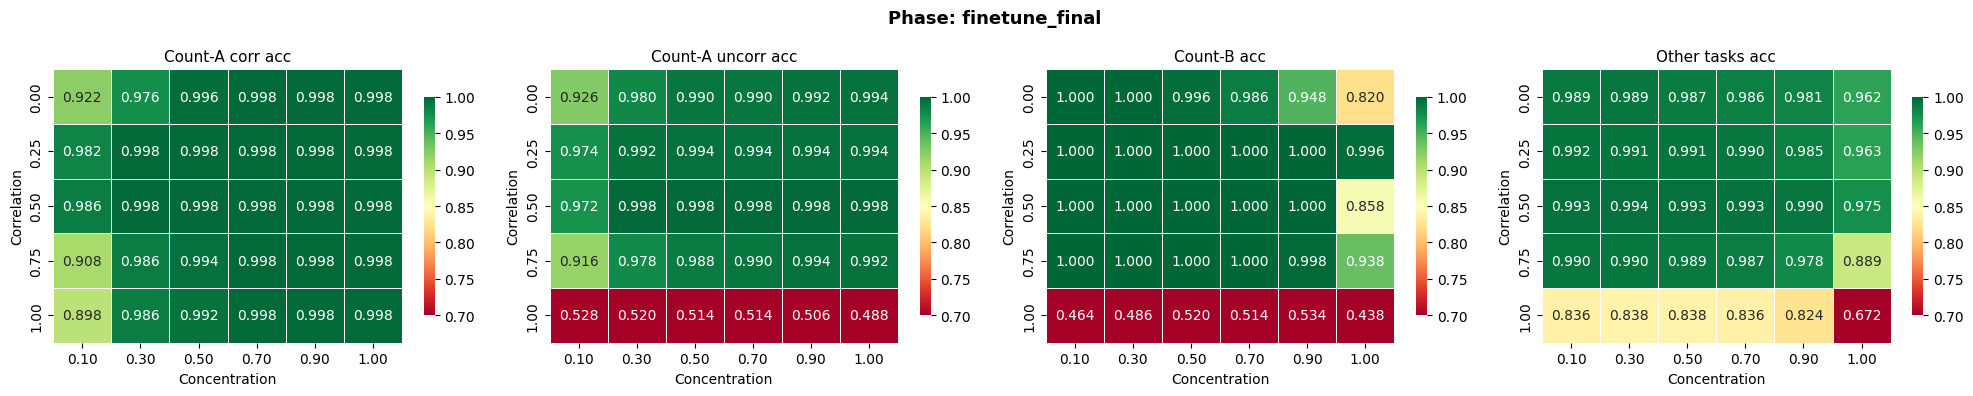

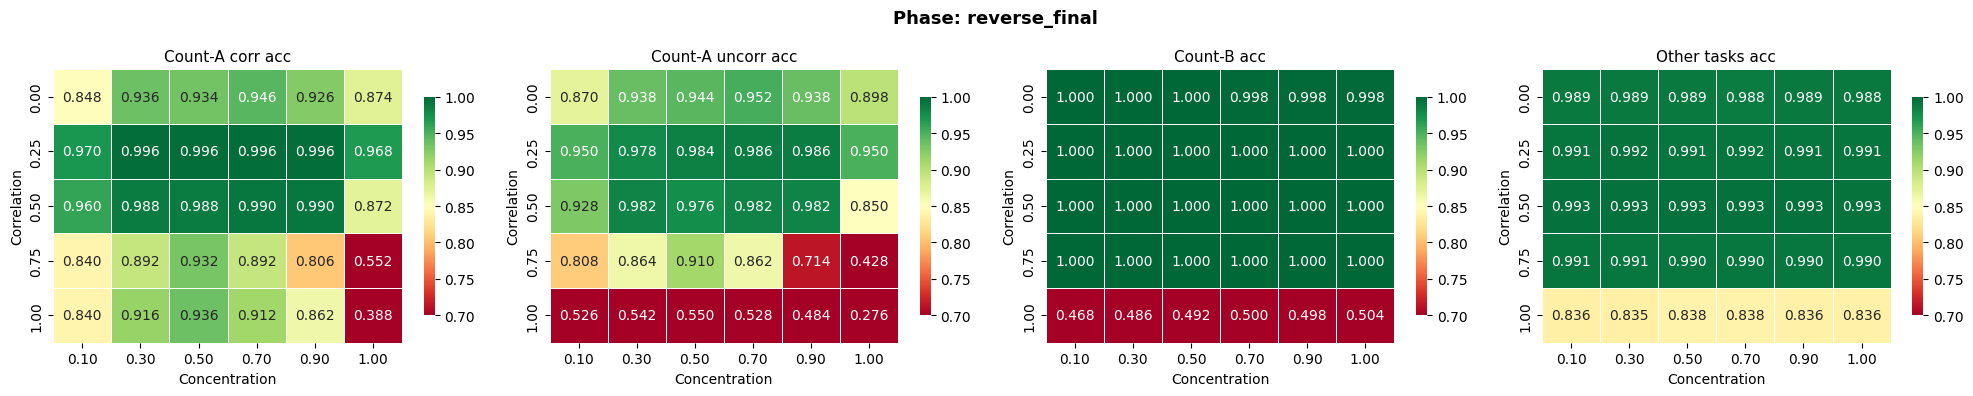

In [ ]:
acc_metrics = ['count_a_corr_acc', 'count_a_uncorr_acc', 'count_b_acc', 'all_other_avg_acc']
acc_titles  = ['Count-A corr acc', 'Count-A uncorr acc', 'Count-B acc', 'Other tasks acc']

make_heatmap_grid(
    phase='finetune_final',
    metrics=acc_metrics, titles=acc_titles,
    cmaps=['RdYlGn'] * 4,
    figsize=(20, 4), vmin=0.7, vmax=1.0,
)

make_heatmap_grid(
    phase='reverse_final',
    metrics=acc_metrics, titles=acc_titles,
    cmaps=['RdYlGn'] * 4,
    figsize=(20, 4), vmin=0.7, vmax=1.0,
)

## Heatmaps — raw loss

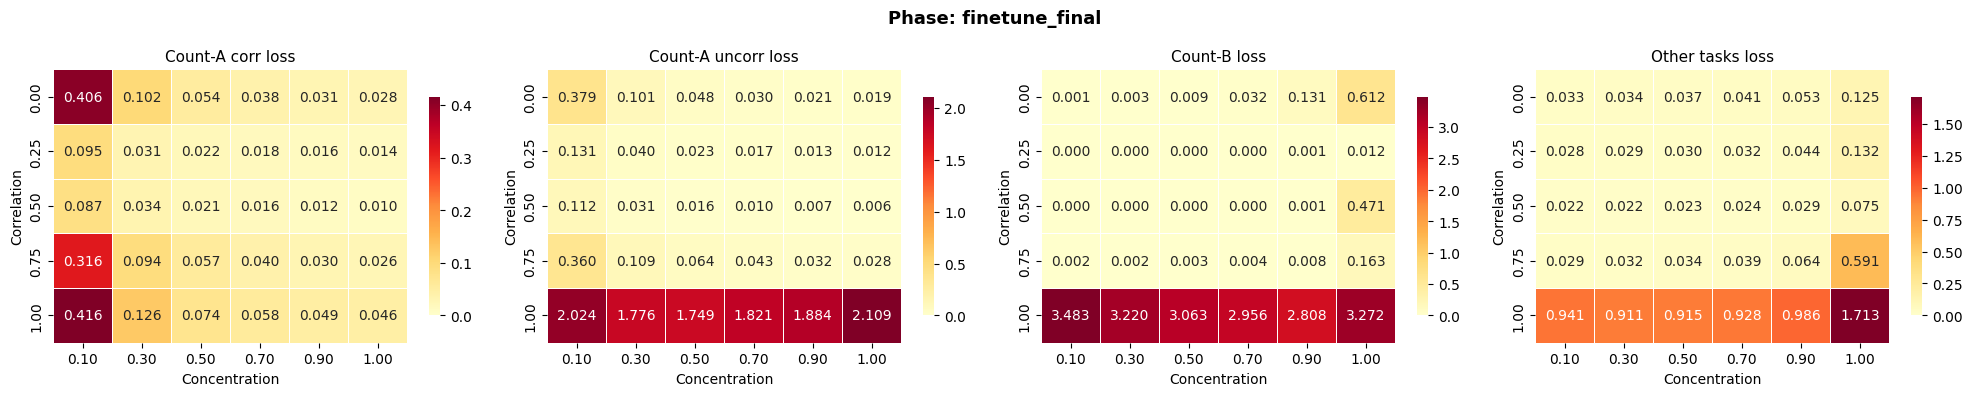

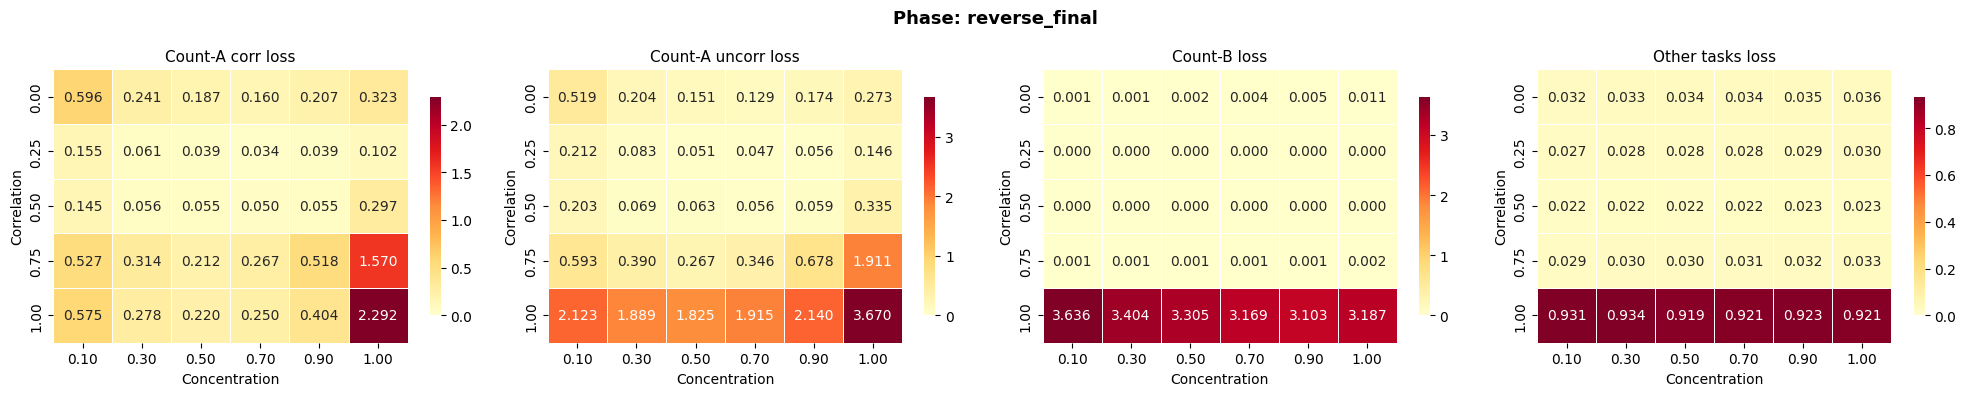

In [ ]:
loss_metrics = ['count_a_corr_loss', 'count_a_uncorr_loss', 'count_b_loss', 'all_other_avg_loss']
loss_titles  = ['Count-A corr loss', 'Count-A uncorr loss', 'Count-B loss', 'Other tasks loss']

make_heatmap_grid(
    phase='finetune_final',
    metrics=loss_metrics, titles=loss_titles,
    cmaps=['YlOrRd'] * 4,
    figsize=(20, 4),
)

make_heatmap_grid(
    phase='reverse_final',
    metrics=loss_metrics, titles=loss_titles,
    cmaps=['YlOrRd'] * 4,
    figsize=(20, 4),
)

## Δ-forgetting: reverse − finetune

How much does the reverse phase *recover* (positive = more forgetting after reverse, negative = recovery).

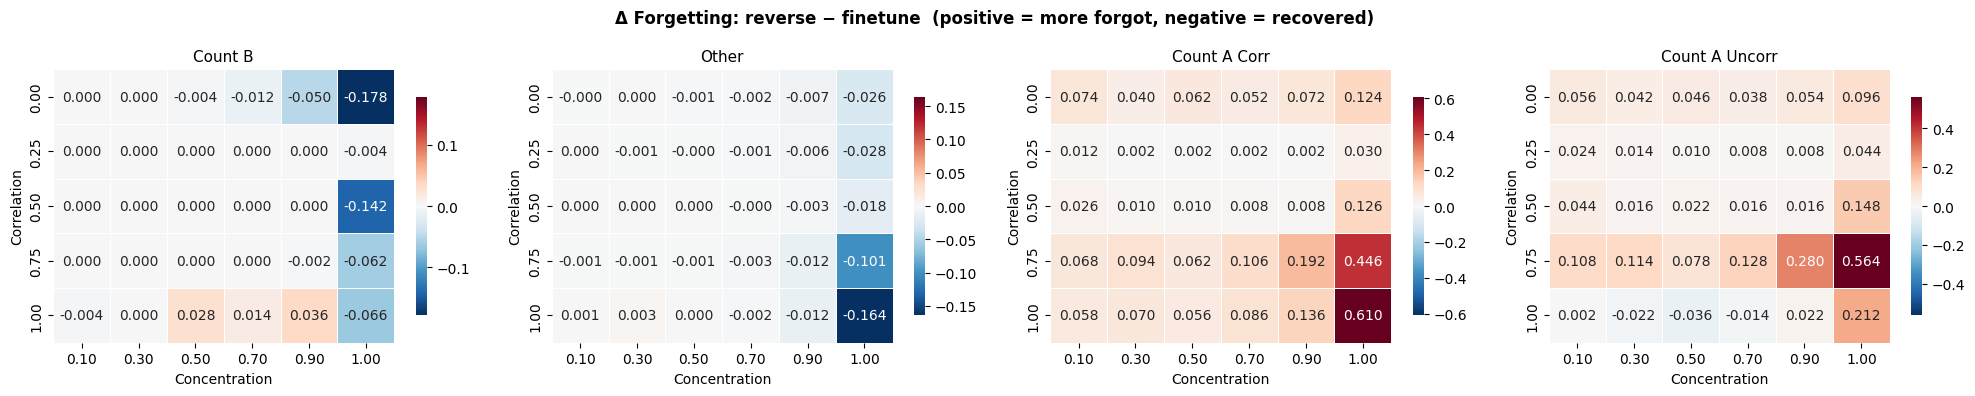

In [ ]:
ft = df[df['phase'] == 'finetune_final'].set_index(['corr', 'conc'])
rv = df[df['phase'] == 'reverse_final'].set_index(['corr', 'conc'])

delta_metrics = ['forget_count_b', 'forget_other',
                 'forget_count_a_corr', 'forget_count_a_uncorr']

delta_df = (rv[delta_metrics] - ft[delta_metrics]).reset_index()

fig, axes = plt.subplots(1, len(delta_metrics), figsize=(20, 4))
fig.suptitle('Δ Forgetting: reverse − finetune  (positive = more forgot, negative = recovered)',
             fontsize=12, fontweight='bold')

for ax, metric in zip(axes, delta_metrics):
    pivot = delta_df.pivot(index='corr', columns='conc', values=metric)
    pivot.index   = [f'{v:.2f}' for v in pivot.index]
    pivot.columns = [f'{v:.2f}' for v in pivot.columns]
    vabs = max(abs(pivot.values.min()), abs(pivot.values.max()))
    sns.heatmap(pivot, ax=ax, cmap='RdBu_r', annot=True, fmt='.3f',
                vmin=-vabs, vmax=vabs,
                linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
    ax.set_title(metric.replace('forget_', '').replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Concentration')
    ax.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

In [79]:
# Evaluate pretrained models on all val splits
import sys
sys.path.insert(0, '/workspace/PCFG')

from mingpt import GPT, GPTConfig
from pcfg_gen import CharTokenizer, PCFGGenerator, PCFGDataset, build_pools, format_example, collate_fn
from config import CFG
from config_utils import build_task_registry, set_seed
from train_help import _evaluate_loader
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = CharTokenizer()
mcfg = CFG['model']
gpt_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    block_size=mcfg['block_size'],
    n_layer=mcfg['n_layer'],
    n_head=mcfg['n_head'],
    n_embd=mcfg['n_embd'],
    embd_pdrop=0.0, resid_pdrop=0.0, attn_pdrop=0.0,
)

set_seed(42)
pcfg = PCFGGenerator()
task_registry = build_task_registry(CFG['task_definitions'])
pools = build_pools(pcfg_gen=pcfg, n_correlated=5000, n_uncorrelated=5000,
                    chunk_size=250, verbose=True)

N_EVAL = 200
max_len = CFG['tokenizer']['max_length']
other_tasks = [t for t in CFG['task_sets']['all'] if t not in ['count_a', 'count_b']]

def make_ds(pool, tasks, n):
    import random
    examples = []
    for _ in range(n):
        s = random.choice(pool)
        t = random.choice(tasks)
        td, ans = task_registry.apply_task(t, s)
        examples.append(format_example(s, td, ans))
    return PCFGDataset(examples, tokenizer, max_length=max_len, mask_answer_only=True)

eval_datasets = {
    'count_a_corr':     make_ds(pools['correlated'],   ['count_a'], N_EVAL),
    'count_a_uncorr':   make_ds(pools['uncorrelated'], ['count_a'], N_EVAL),
    'count_b_corr':     make_ds(pools['correlated'],   ['count_b'], N_EVAL),
    'count_b_uncorr':   make_ds(pools['uncorrelated'], ['count_b'], N_EVAL),
    'all_other_corr':   make_ds(pools['correlated'],   other_tasks, N_EVAL * len(other_tasks)),
    'all_other_uncorr': make_ds(pools['uncorrelated'], other_tasks, N_EVAL * len(other_tasks)),
}
eval_loaders = {
    name: DataLoader(ds, batch_size=64, shuffle=False,
                     collate_fn=lambda b, tok=tokenizer: collate_fn(b, tok))
    for name, ds in eval_datasets.items()
}

PRETRAIN_DIR = '/workspace/PCFG'

pretrain_accs = {}  # corr -> {split: acc}
for corr in CORRS:
    path = f'{PRETRAIN_DIR}/pretrain_corr_{corr:.2f}.pth'
    if not os.path.exists(path):
        print(f'  Missing pretrain for corr={corr:.2f}')
        continue
    ck = torch.load(path, map_location='cpu')
    model = GPT(gpt_config).to(device)
    model.load_state_dict(ck['model_state_dict'])
    model.eval()
    pretrain_accs[corr] = {}
    for name, loader in eval_loaders.items():
        loss, acc = _evaluate_loader(model, loader, device, metrics_set={'loss', 'answer_acc'})
        pretrain_accs[corr][name] = acc
    del model
    print(f'corr={corr:.2f}: {pretrain_accs[corr]}')

print('\nDone evaluating pretrained models')


Tokenizer vocabulary size: 267
Building PCFG pools: 5,000 correlated + 5,000 uncorrelated strings …
  generated 50,000 | correlated 4,573/5,000 (9.1% acceptance)
Pools ready — 5,000 correlated, 5,000 uncorrelated from 54,442 total generations (9.2% acceptance rate).
number of parameters: 2.82M
corr=0.25: {'count_a_corr': 0.295, 'count_a_uncorr': 0.29, 'count_b_corr': 1.0, 'count_b_uncorr': 1.0, 'all_other_corr': 0.9931818181818182, 'all_other_uncorr': 0.9895454545454545}
number of parameters: 2.82M
corr=1.00: {'count_a_corr': 0.24, 'count_a_uncorr': 0.165, 'count_b_corr': 1.0, 'count_b_uncorr': 0.39, 'all_other_corr': 0.98, 'all_other_uncorr': 0.8281818181818181}

Done evaluating pretrained models


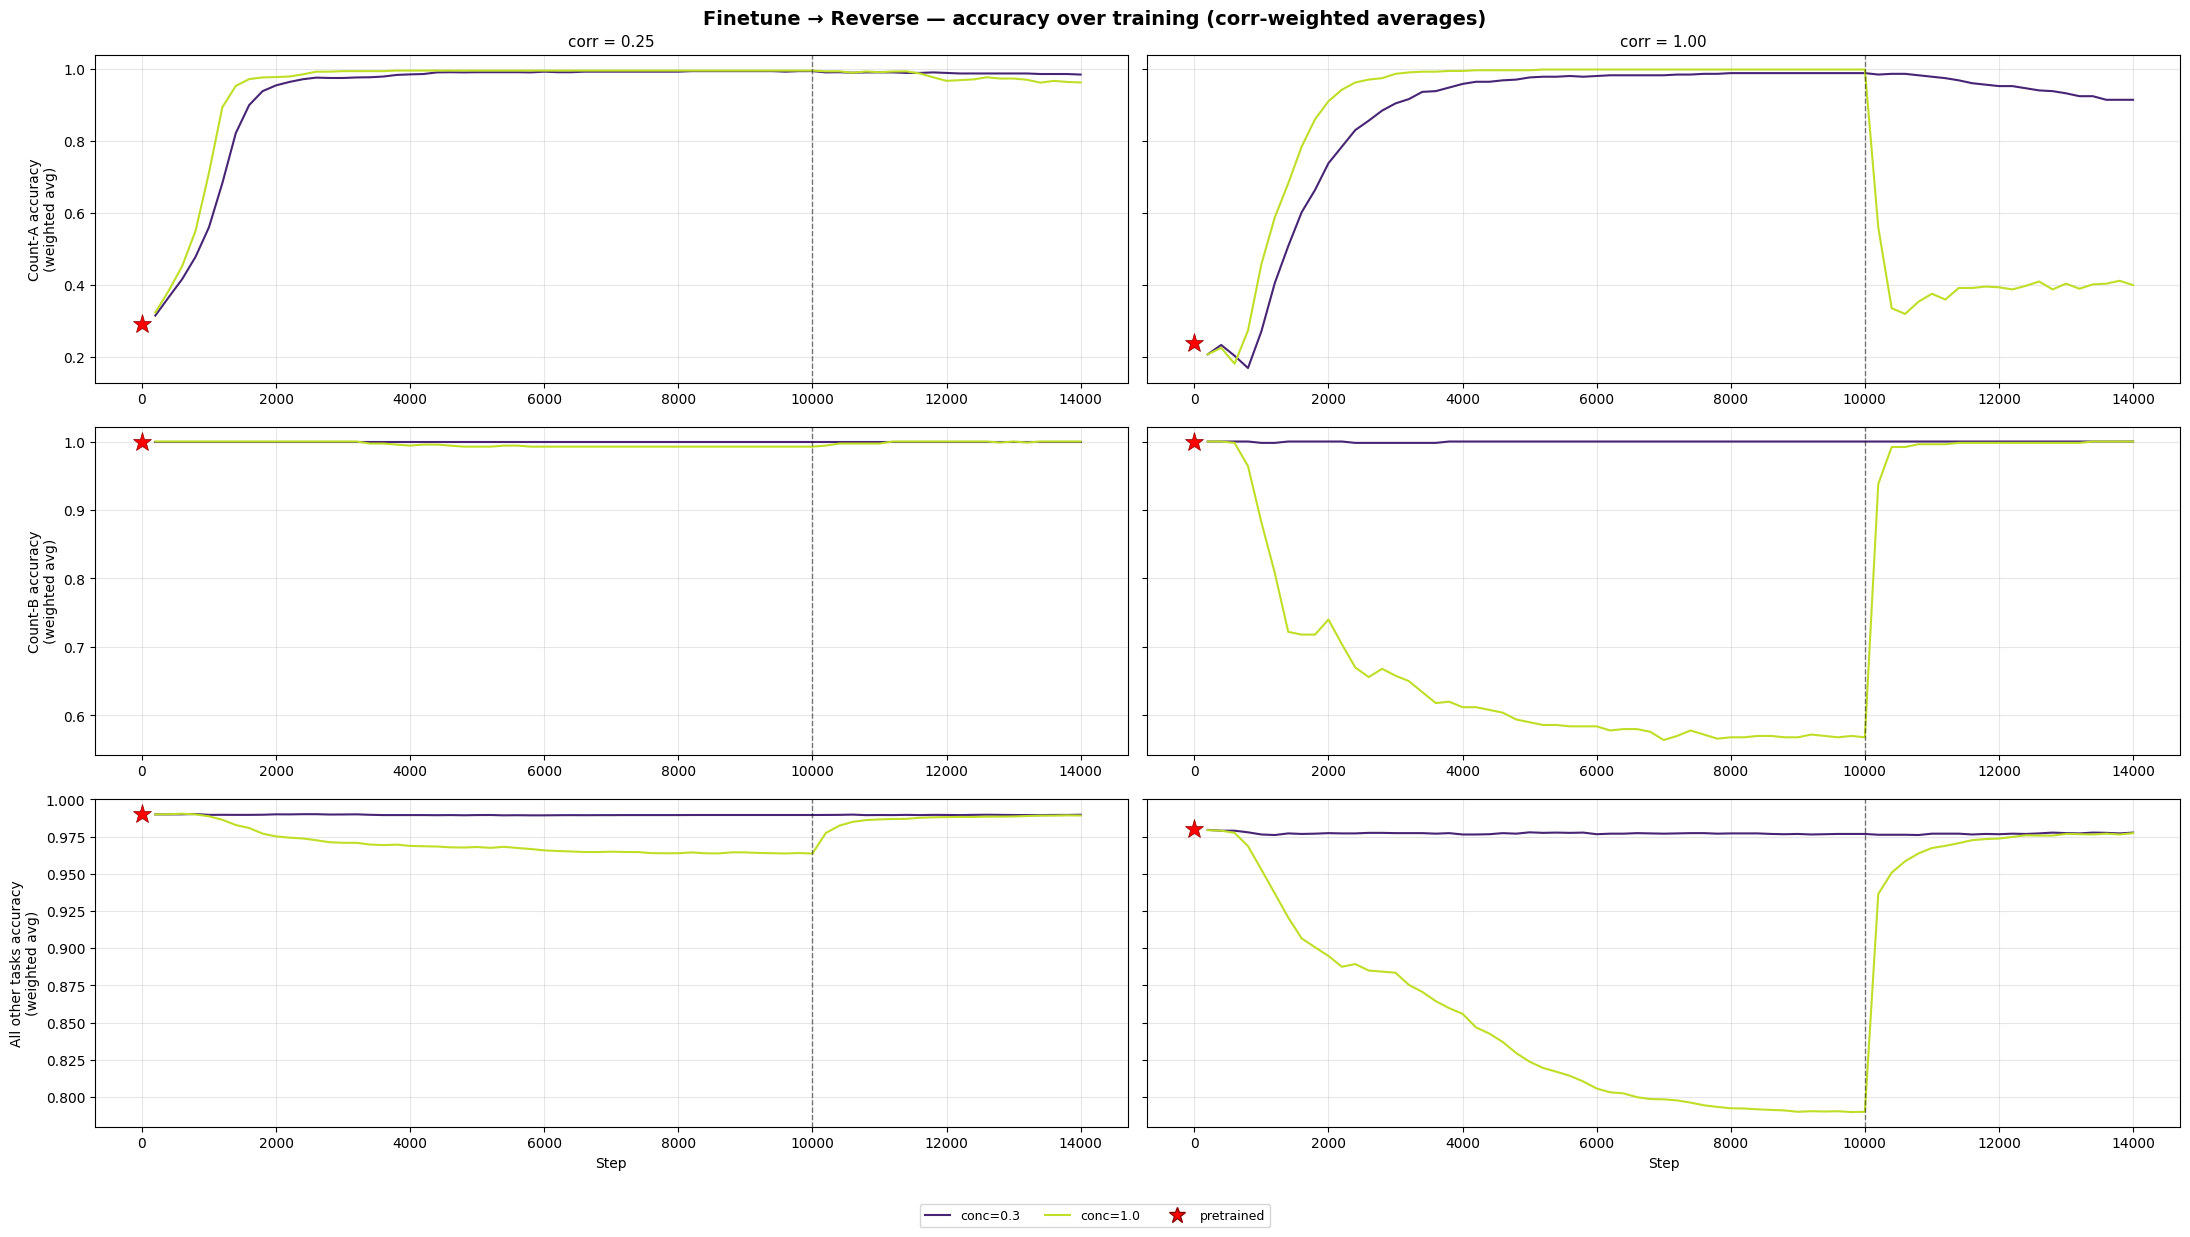

In [80]:
# Combined finetune → reverse: 3 rows, each using corr-weighted average
# Red star at step=0 = pretrained model accuracy

CONC_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONCS)))

row_specs = [
    ('count_a_avg',   'Count-A accuracy\n(weighted avg)'),
    ('count_b_avg',   'Count-B accuracy\n(weighted avg)'),
    ('all_other_avg', 'All other tasks accuracy\n(weighted avg)'),
]

def get_weighted_vals(hist, weighted_key, corr, metric='answer_acc'):
    """Get corr-weighted average from history, with fallback for old key names."""
    corr_split, uncorr_split = WEIGHTED_SPLITS[weighted_key]
    if corr_split in hist['val']:
        return corr * np.array(hist['val'][corr_split][metric]) + \
               (1 - corr) * np.array(hist['val'][uncorr_split][metric])
    # Fallback for old histories that used unsplit keys
    old_key = weighted_key.replace('_avg', '') if weighted_key != 'all_other_avg' else 'all_other_avg'
    if old_key in hist['val']:
        return np.array(hist['val'][old_key][metric])
    # Try without _avg
    old_key2 = weighted_key.replace('_avg', '')
    if old_key2 in hist['val']:
        return np.array(hist['val'][old_key2][metric])
    return None

fig, axes = plt.subplots(len(row_specs), len(CORRS), figsize=(22, 12), sharey='row')
fig.suptitle('Finetune → Reverse — accuracy over training (corr-weighted averages)',
             fontsize=14, fontweight='bold')

boundary_step = None

for row, (split_key, ylabel) in enumerate(row_specs):
    for col, corr in enumerate(CORRS):
        ax = axes[row, col]

        for conc, color in zip(CONCS, CONC_COLORS):
            ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
            rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'
            if ft_key not in histories or rv_key not in histories:
                continue

            ft_vals = get_weighted_vals(histories[ft_key], split_key, corr)
            rv_vals = get_weighted_vals(histories[rv_key], split_key, corr)
            if ft_vals is None or rv_vals is None:
                continue

            ft_steps = histories[ft_key]['steps']
            ft_last  = ft_steps[-1]
            rv_steps = [ft_last + s for s in histories[rv_key]['steps']]

            if boundary_step is None:
                boundary_step = ft_last

            steps = list(ft_steps) + list(rv_steps)
            vals  = list(ft_vals)  + list(rv_vals)

            ax.plot(steps, vals, color=color, linewidth=1.5, label=f'conc={conc:.1f}')

        # Red star for pretrained model accuracy at step 0
        if corr in pretrain_accs:
            corr_split, uncorr_split = WEIGHTED_SPLITS[split_key]
            if corr_split in pretrain_accs[corr]:
                pval = corr * pretrain_accs[corr][corr_split] + \
                       (1 - corr) * pretrain_accs[corr][uncorr_split]
            else:
                pval = pretrain_accs[corr].get(split_key, None)
            if pval is not None:
                ax.plot(0, pval, marker='*', color='red', markersize=14, zorder=5,
                        markeredgecolor='darkred', markeredgewidth=0.5)

        ax.axvline(boundary_step, color='black', linestyle='--', alpha=0.5, linewidth=1)
        ax.grid(True, alpha=0.3)

        if row == 0:
            ax.set_title(f'corr = {corr:.2f}', fontsize=11)
        if row == len(row_specs) - 1:
            ax.set_xlabel('Step')
        if col == 0:
            ax.set_ylabel(ylabel)

# Legend
handles, labels = axes[0, 0].get_legend_handles_labels()
from matplotlib.lines import Line2D
pretrain_handle = Line2D([0], [0], marker='*', color='red', markersize=12,
                         markeredgecolor='darkred', linestyle='None', label='pretrained')
handles.append(pretrain_handle)
labels.append('pretrained')

fig.legend(handles, labels, loc='lower center', ncol=len(CONCS) + 1,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()


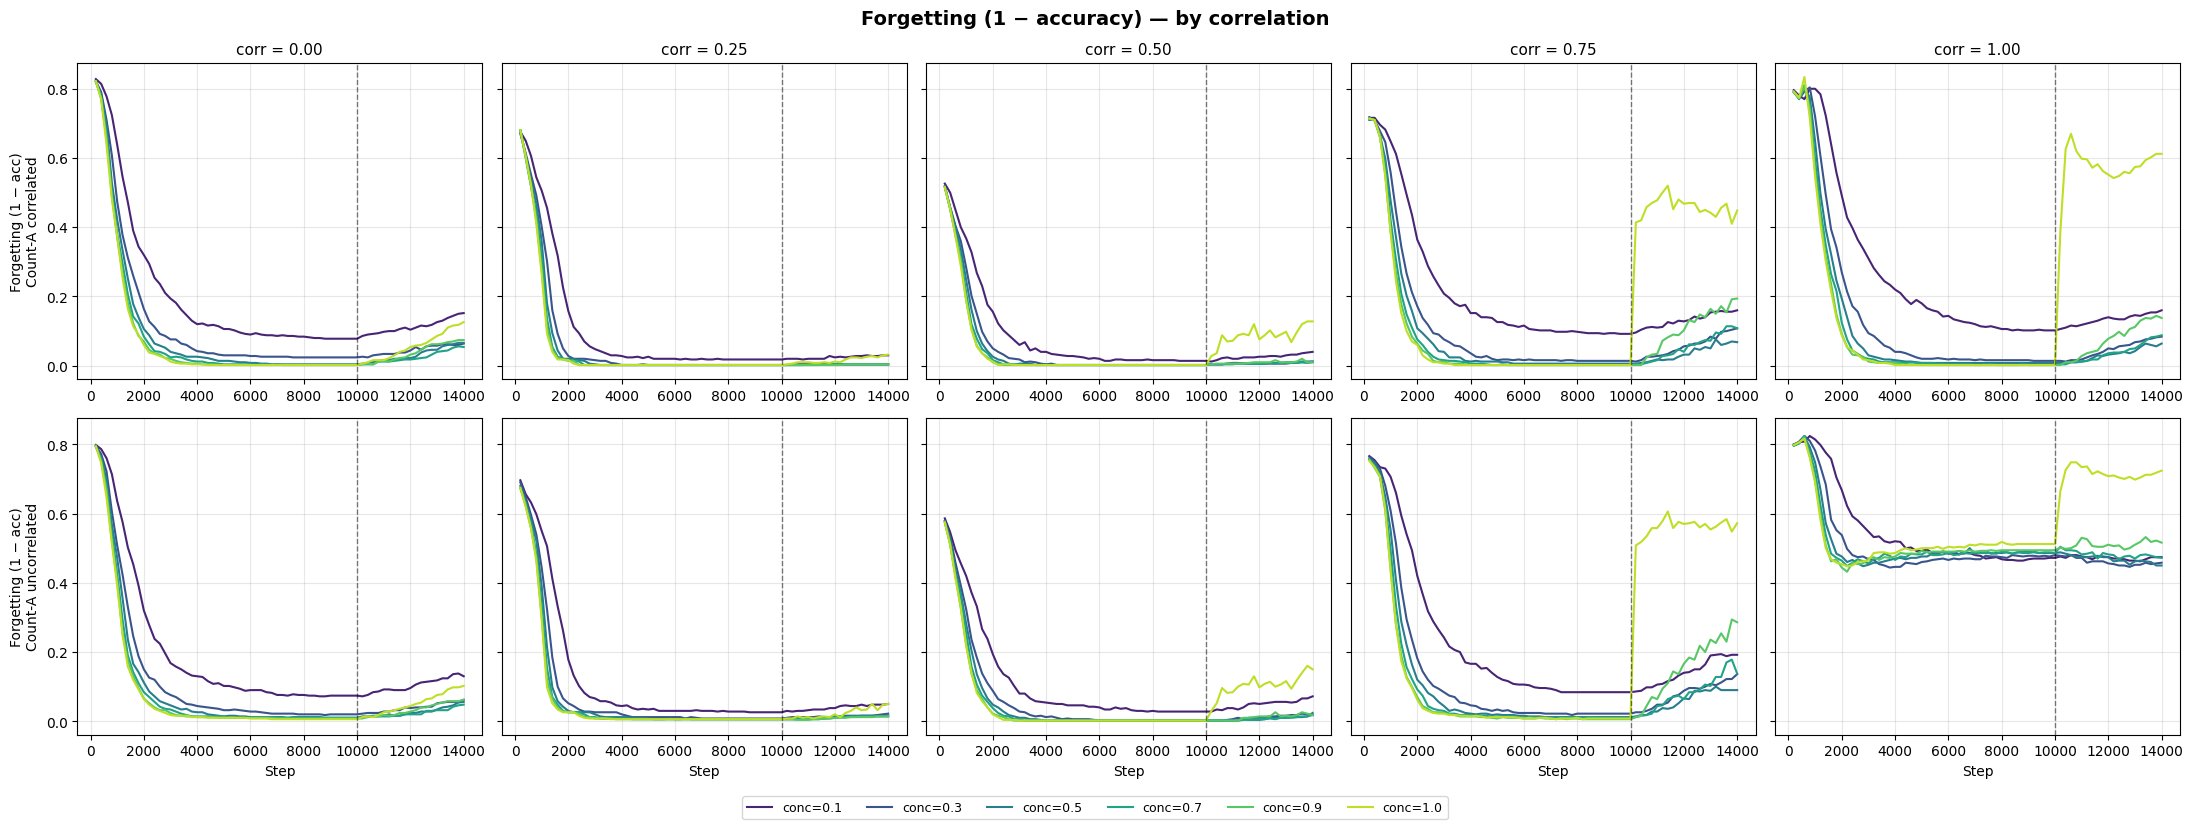

In [35]:

# 2x5 subplots — top row: count_a_corr, bottom row: count_a_uncorr
# One column per correlation, all concentrations on each

CONC_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONCS)))

splits = ['count_a_corr', 'count_a_uncorr']
split_titles = {'count_a_corr': 'Count-A correlated', 'count_a_uncorr': 'Count-A uncorrelated'}
metric = 'answer_acc'

fig, axes = plt.subplots(2, len(CORRS), figsize=(22, 8), sharey=True)
fig.suptitle('Forgetting (1 − accuracy) — by correlation',
             fontsize=14, fontweight='bold')

for row, split in enumerate(splits):
    for col, corr in enumerate(CORRS):
        ax = axes[row, col]
        for conc, color in zip(CONCS, CONC_COLORS):
            ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
            rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'
            if ft_key not in histories or rv_key not in histories:
                continue

            ft_h = histories[ft_key]
            rv_h = histories[rv_key]

            ft_steps = ft_h['steps']
            ft_vals  = [1.0 - v for v in ft_h['val'][split][metric]]

            ft_last  = ft_steps[-1]
            rv_steps = [ft_last + s for s in rv_h['steps']]
            rv_vals  = [1.0 - v for v in rv_h['val'][split][metric]]

            steps = list(ft_steps) + list(rv_steps)
            vals  = list(ft_vals)  + list(rv_vals)

            ax.plot(steps, vals, color=color, linewidth=1.5, label=f'conc={conc:.1f}')

        ax.axvline(ft_last, color='black', linestyle='--', alpha=0.5, linewidth=1)
        ax.grid(True, alpha=0.3)

        if row == 0:
            ax.set_title(f'corr = {corr:.2f}', fontsize=11)
        if row == 1:
            ax.set_xlabel('Step')

    axes[row, 0].set_ylabel(f'Forgetting (1 − acc)\n{split_titles[split]}')

# shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(CONCS),
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()


## Neuron pruning experiment (gradient × weight saliency)

Following the paper: compute gradients of the **pretraining task loss** (count_b) w.r.t. model weights,
rank MLP neurons by `grad · weight` saliency, then zero out the top-k most salient neurons.
If finetuning learned a "wrapper", pruning a small number of neurons should recover count_b performance.

In [91]:
import sys, os
sys.path.insert(0, '/workspace/PCFG')

from copy import deepcopy
from mingpt import GPT, GPTConfig
from pcfg_gen import CharTokenizer, PCFGGenerator, PCFGDataset, build_pools, format_example, collate_fn
from config import CFG
from config_utils import build_task_registry, set_seed
from train_help import _evaluate_loader
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ---- tokenizer & model config ----
tokenizer = CharTokenizer()
mcfg = CFG['model']
gpt_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    block_size=mcfg['block_size'],
    n_layer=mcfg['n_layer'],
    n_head=mcfg['n_head'],
    n_embd=mcfg['n_embd'],
    embd_pdrop=0.0, resid_pdrop=0.0, attn_pdrop=0.0,
)

# ---- build eval loaders ----
set_seed(42)
pcfg = PCFGGenerator()
task_registry = build_task_registry(CFG['task_definitions'])

print("Building string pools...")
pools = build_pools(pcfg_gen=pcfg, n_correlated=5000, n_uncorrelated=5000,
                    chunk_size=250, verbose=True)

N_EVAL = 200
max_len = CFG['tokenizer']['max_length']

def make_ds(pool, tasks, n):
    import random
    examples = []
    for _ in range(n):
        s = random.choice(pool)
        t = random.choice(tasks)
        td, ans = task_registry.apply_task(t, s)
        examples.append(format_example(s, td, ans))
    return PCFGDataset(examples, tokenizer, max_length=max_len, mask_answer_only=True)

other_tasks = [t for t in CFG['task_sets']['all'] if t not in ['count_a', 'count_b']]

eval_datasets = {
    'count_a_corr':     make_ds(pools['correlated'],   ['count_a'], N_EVAL),
    'count_a_uncorr':   make_ds(pools['uncorrelated'], ['count_a'], N_EVAL),
    'count_b_corr':     make_ds(pools['correlated'],   ['count_b'], N_EVAL),
    'count_b_uncorr':   make_ds(pools['uncorrelated'], ['count_b'], N_EVAL),
    'all_other_corr':   make_ds(pools['correlated'],   other_tasks, N_EVAL * len(other_tasks)),
    'all_other_uncorr': make_ds(pools['uncorrelated'], other_tasks, N_EVAL * len(other_tasks)),
}
eval_loaders = {
    name: DataLoader(ds, batch_size=64, shuffle=False,
                     collate_fn=lambda b, tok=tokenizer: collate_fn(b, tok))
    for name, ds in eval_datasets.items()
}
print("Eval sets:", {k: len(v.dataset) for k, v in eval_loaders.items()})

Device: cuda
Tokenizer vocabulary size: 267
Building string pools...
Building PCFG pools: 5,000 correlated + 5,000 uncorrelated strings …
  generated 50,000 | correlated 4,573/5,000 (9.1% acceptance)
Pools ready — 5,000 correlated, 5,000 uncorrelated from 54,442 total generations (9.2% acceptance rate).
Eval sets: {'count_a_corr': 200, 'count_a_uncorr': 200, 'count_b_corr': 200, 'count_b_uncorr': 200, 'all_other_corr': 2200, 'all_other_uncorr': 2200}


In [92]:
PRETRAIN_DIR = '/workspace/PCFG'
MODELS_DIR   = '/workspace/PCFG/results/models'

def load_state(path):
    ck = torch.load(path, map_location='cpu')
    return ck['model_state_dict']

def compute_neuron_saliency(model, loaders_with_weights, device, n_layers=6):
    """
    Compute gradient * weight saliency for each MLP neuron.
    loaders_with_weights: list of (loader, weight) tuples.
      The loss is a weighted sum across loaders, matching the training data mix.
    Returns array of shape (n_layers, n_neurons).
    """
    model.train()
    model.zero_grad()

    for loader, w in loaders_with_weights:
        if w == 0:
            continue
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            logits, loss = model(input_ids, target_ids)
            (loss * w).backward()

    n_neurons = 4 * mcfg['n_embd']  # 768
    saliency = np.zeros((n_layers, n_neurons))

    for l in range(n_layers):
        fc_w = model.transformer.h[l].mlp.c_fc.weight
        neuron_fc_sal = (fc_w.grad * fc_w).detach().sum(dim=1).cpu().numpy()

        fc_b = model.transformer.h[l].mlp.c_fc.bias
        neuron_bias_sal = (fc_b.grad * fc_b).detach().cpu().numpy()

        proj_w = model.transformer.h[l].mlp.c_proj.weight
        neuron_proj_sal = (proj_w.grad * proj_w).detach().sum(dim=0).cpu().numpy()

        saliency[l] = neuron_fc_sal + neuron_bias_sal + neuron_proj_sal

    model.zero_grad()
    return saliency

def prune_neurons(state_dict, saliency, k):
    """Zero out top-k neurons by saliency score."""
    state = deepcopy(state_dict)
    n_layers, n_neurons = saliency.shape
    flat = saliency.flatten()
    if k == 0:
        return state
    selected = np.argsort(flat)[::-1][:k]
    for idx in selected:
        l = idx // n_neurons
        j = idx %  n_neurons
        fc_key   = f'transformer.h.{l}.mlp.c_fc.weight'
        proj_key = f'transformer.h.{l}.mlp.c_proj.weight'
        fc_bias  = f'transformer.h.{l}.mlp.c_fc.bias'
        state[fc_key][j, :]   = 0.0
        state[proj_key][:, j] = 0.0
        if fc_bias in state:
            state[fc_bias][j] = 0.0
    return state

def eval_state(state_dict, loaders, device):
    model = GPT(gpt_config).to(device)
    model.load_state_dict(state_dict)
    model.eval()
    results = {}
    for name, loader in loaders.items():
        loss, acc = _evaluate_loader(model, loader, device, metrics_set={'loss', 'answer_acc'})
        results[name] = {'loss': loss, 'acc': acc}
    return results

# ---- Run pruning for all (corr, conc) pairs ----
K_VALUES = [0, 5, 10, 20, 50, 100]

pruning_results = {}

for corr in CORRS:
    for conc in CONCS:
        pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
        finetune_path = f'{MODELS_DIR}/finetune_{pair_name}.pth'
        if not os.path.exists(finetune_path):
            print(f'  Skipping {pair_name} — no finetune checkpoint')
            continue

        print(f"\n{'='*60}")
        print(f'Pruning: {pair_name}')
        ft_state = load_state(finetune_path)

        # Compute saliency using corr-weighted count_b loss
        model = GPT(gpt_config).to(device)
        model.load_state_dict(ft_state)
        saliency_loaders = [
            (eval_loaders['count_b_corr'],   corr),
            (eval_loaders['count_b_uncorr'], 1 - corr),
        ]
        saliency = compute_neuron_saliency(model, saliency_loaders, device)
        print(f'  Saliency — max: {saliency.max():.6f}  mean: {saliency.mean():.6f}')
        del model

        pruning_results[pair_name] = {}
        for k in K_VALUES:
            pruned_state = prune_neurons(ft_state, saliency, k=k)
            res = eval_state(pruned_state, eval_loaders, device)
            pruning_results[pair_name][k] = res
            accs = {s: f"{res[s]['acc']:.3f}" for s in VAL_SPLITS}
            print(f'    k={k:4d}: {accs}')

print('\nDone!')



Pruning: corr_0.25_conc_0.30


number of parameters: 2.82M
  Saliency — max: 0.006710  mean: 0.000008
number of parameters: 2.82M
    k=   0: {'count_a_corr': '0.995', 'count_a_uncorr': '0.990', 'count_b_corr': '1.000', 'count_b_uncorr': '1.000', 'all_other_corr': '0.994', 'all_other_uncorr': '0.990'}
number of parameters: 2.82M
    k=   5: {'count_a_corr': '0.995', 'count_a_uncorr': '0.990', 'count_b_corr': '0.990', 'count_b_uncorr': '0.995', 'all_other_corr': '0.993', 'all_other_uncorr': '0.990'}
number of parameters: 2.82M
    k=  10: {'count_a_corr': '0.975', 'count_a_uncorr': '0.985', 'count_b_corr': '0.935', 'count_b_uncorr': '0.930', 'all_other_corr': '0.989', 'all_other_uncorr': '0.988'}
number of parameters: 2.82M
    k=  20: {'count_a_corr': '0.975', 'count_a_uncorr': '0.965', 'count_b_corr': '0.870', 'count_b_uncorr': '0.865', 'all_other_corr': '0.986', 'all_other_uncorr': '0.980'}
number of parameters: 2.82M
    k=  50: {'count_a_corr': '0.420', 'count_a_uncorr': '0.355', 'count_b_corr': '0.680', 'count_

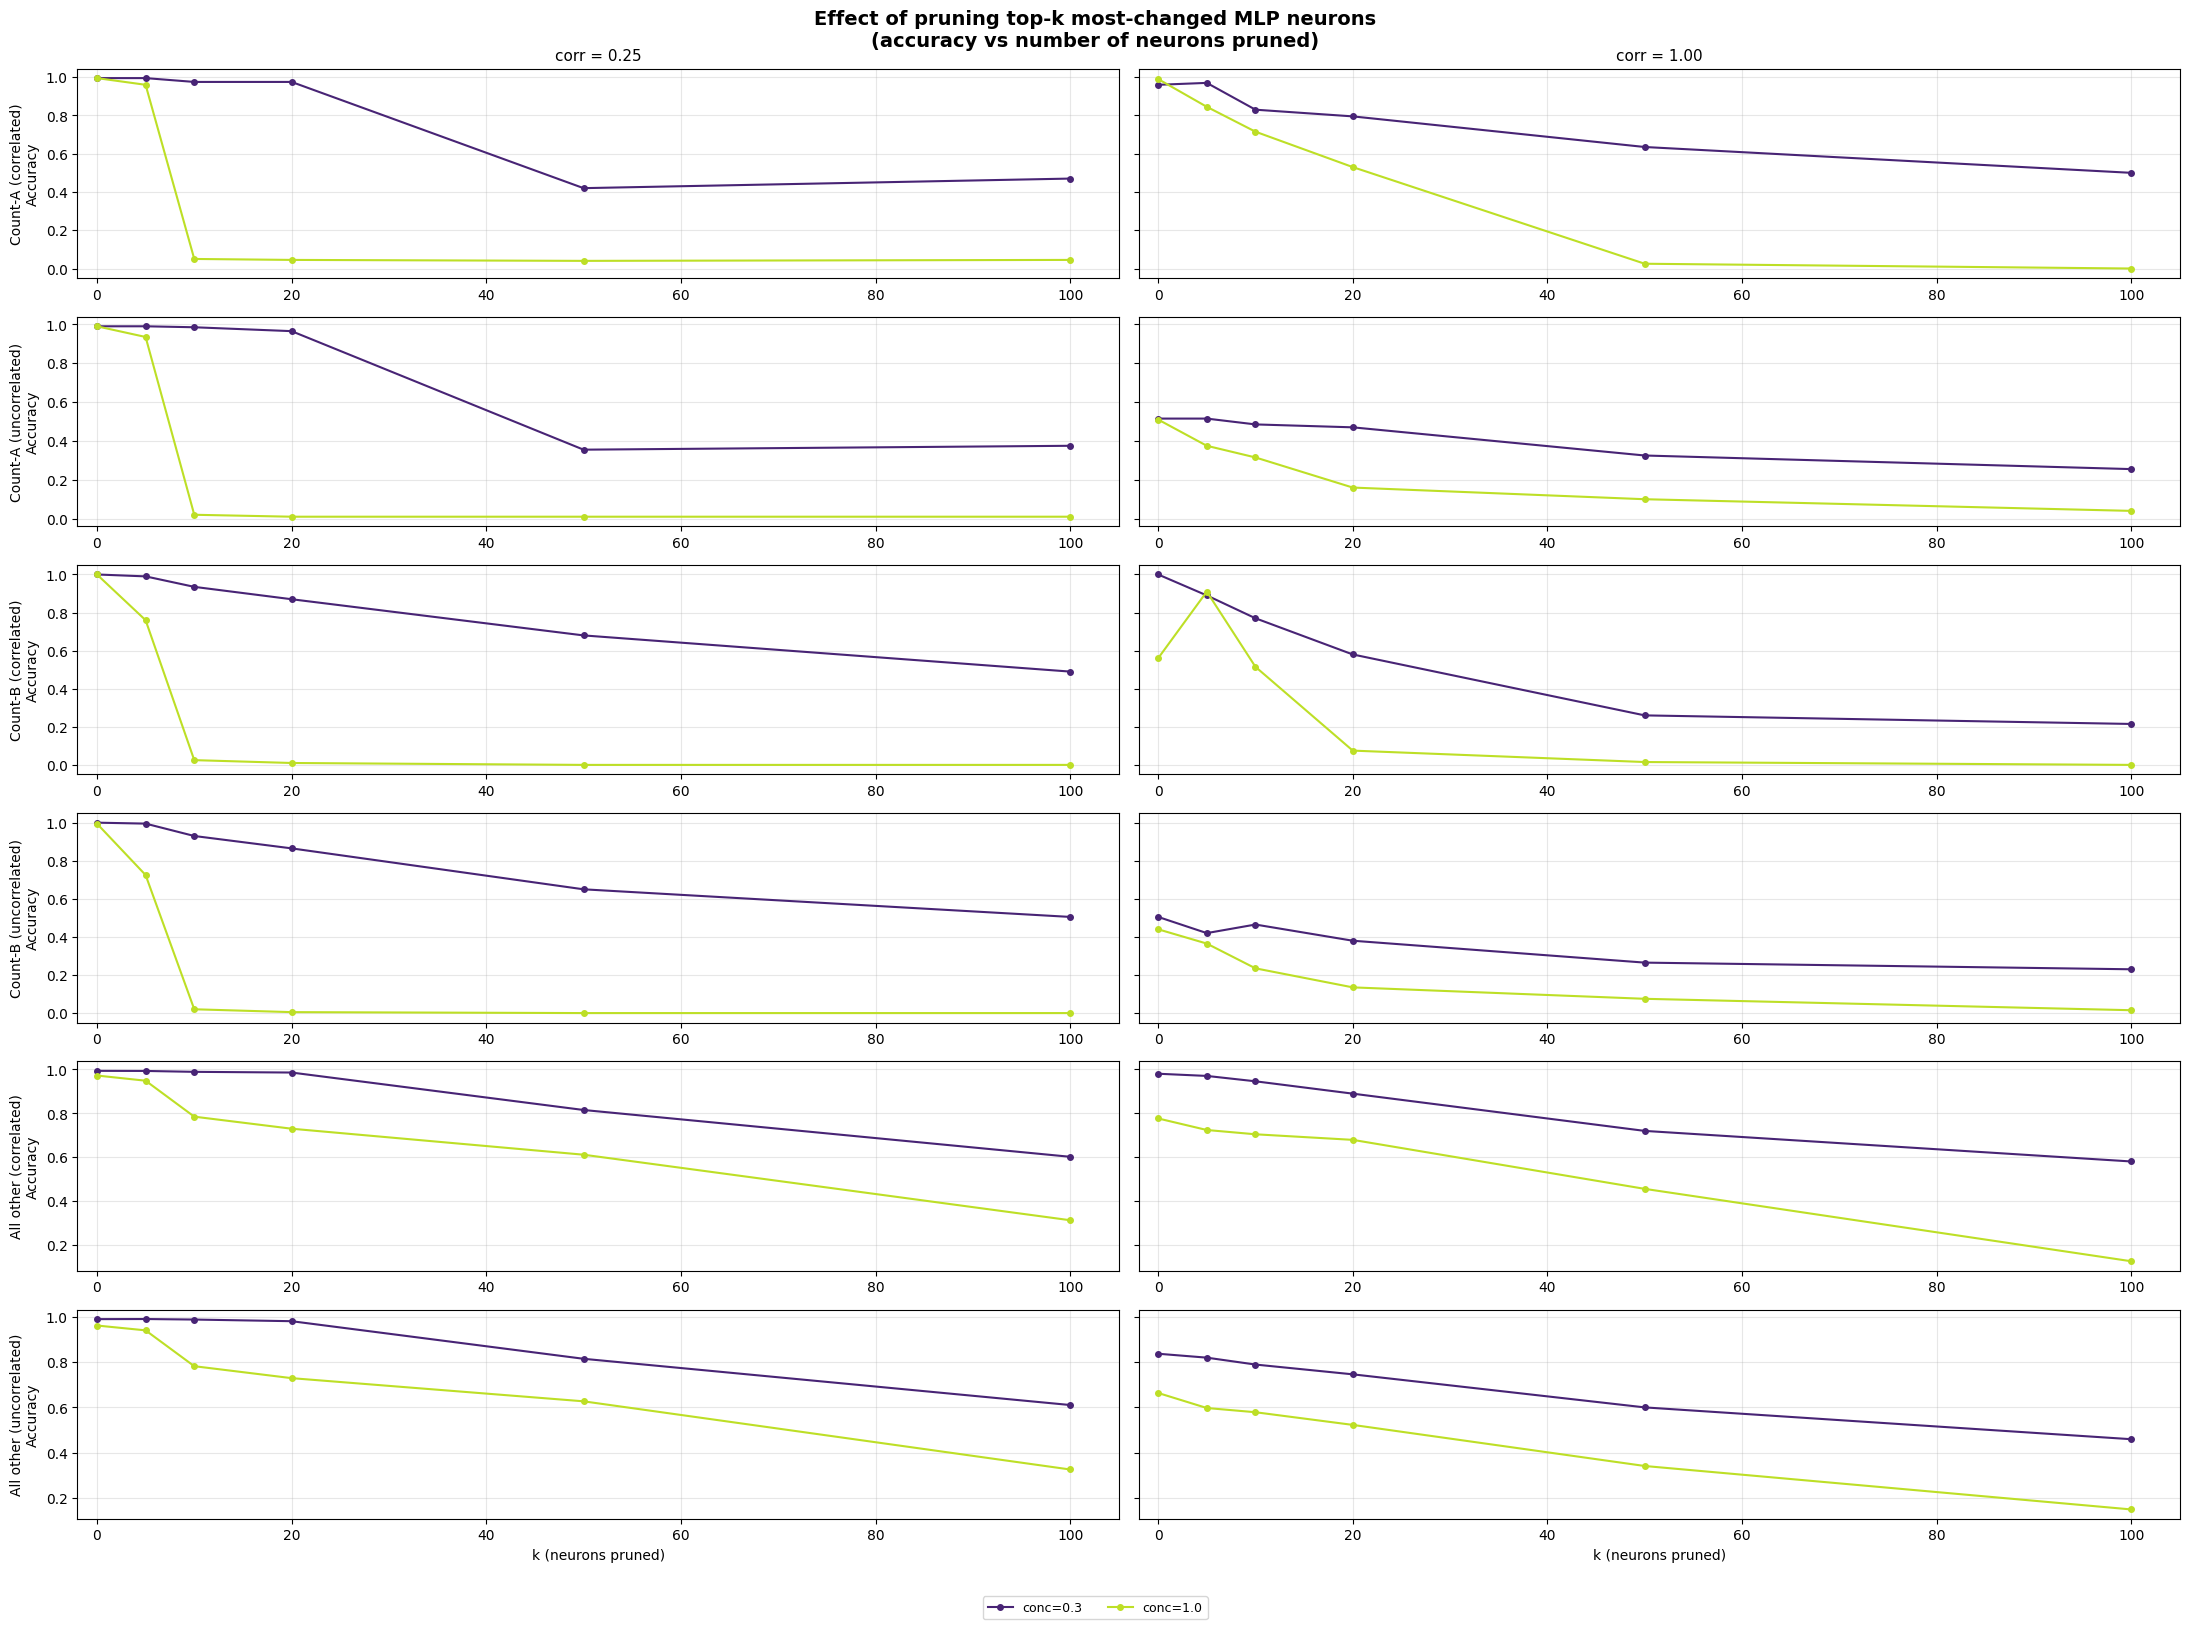

In [93]:
# Plot pruning results: one row per val split, one column per correlation
# Each subplot shows accuracy vs k for all concentrations

CONC_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONCS)))

fig, axes = plt.subplots(len(VAL_SPLITS), len(CORRS), figsize=(22, 16), sharey='row')
fig.suptitle('Effect of pruning top-k most-changed MLP neurons\n(accuracy vs number of neurons pruned)',
             fontsize=14, fontweight='bold')

for row, split in enumerate(VAL_SPLITS):
    for col, corr in enumerate(CORRS):
        ax = axes[row, col]
        for conc, color in zip(CONCS, CONC_COLORS):
            pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
            if pair_name not in pruning_results:
                continue
            ks = sorted(pruning_results[pair_name].keys())
            accs = [pruning_results[pair_name][k][split]['acc'] for k in ks]
            ax.plot(ks, accs, 'o-', color=color, linewidth=1.5, markersize=4,
                    label=f'conc={conc:.1f}')

        ax.set_xlim(-2, max(K_VALUES) + 5)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(f'corr = {corr:.2f}', fontsize=11)
        if row == len(VAL_SPLITS) - 1:
            ax.set_xlabel('k (neurons pruned)')
        if col == 0:
            ax.set_ylabel(f'{SPLIT_LABELS[split]}\nAccuracy')

# shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(CONCS),
           fontsize=9, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.show()

## Weight change per layer: pretrain → finetune

For each MLP neuron, compute `||Δc_fc[j,:]|| + ||Δc_proj[:,j]||` between pretrain and finetune.
Heatmap: neuron index (x) × layer (y).

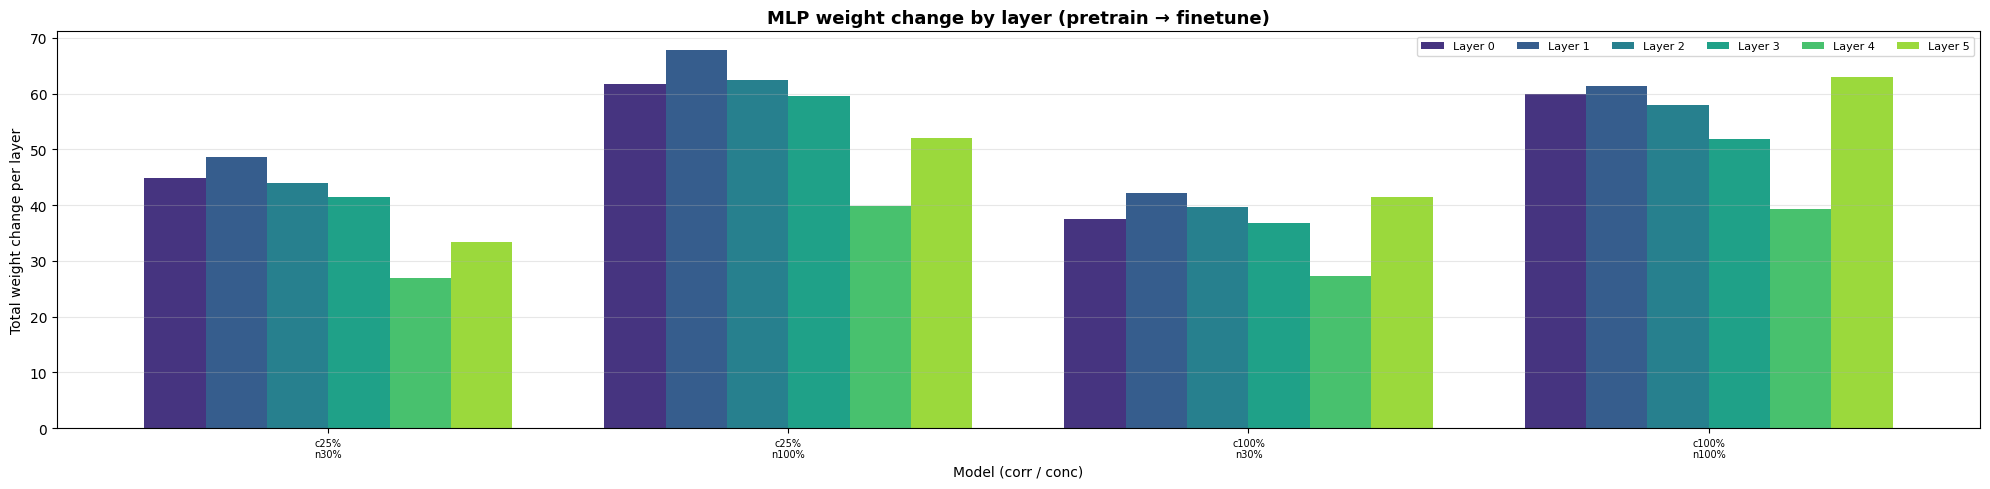

/tmp/ipykernel_79800/2830275264.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


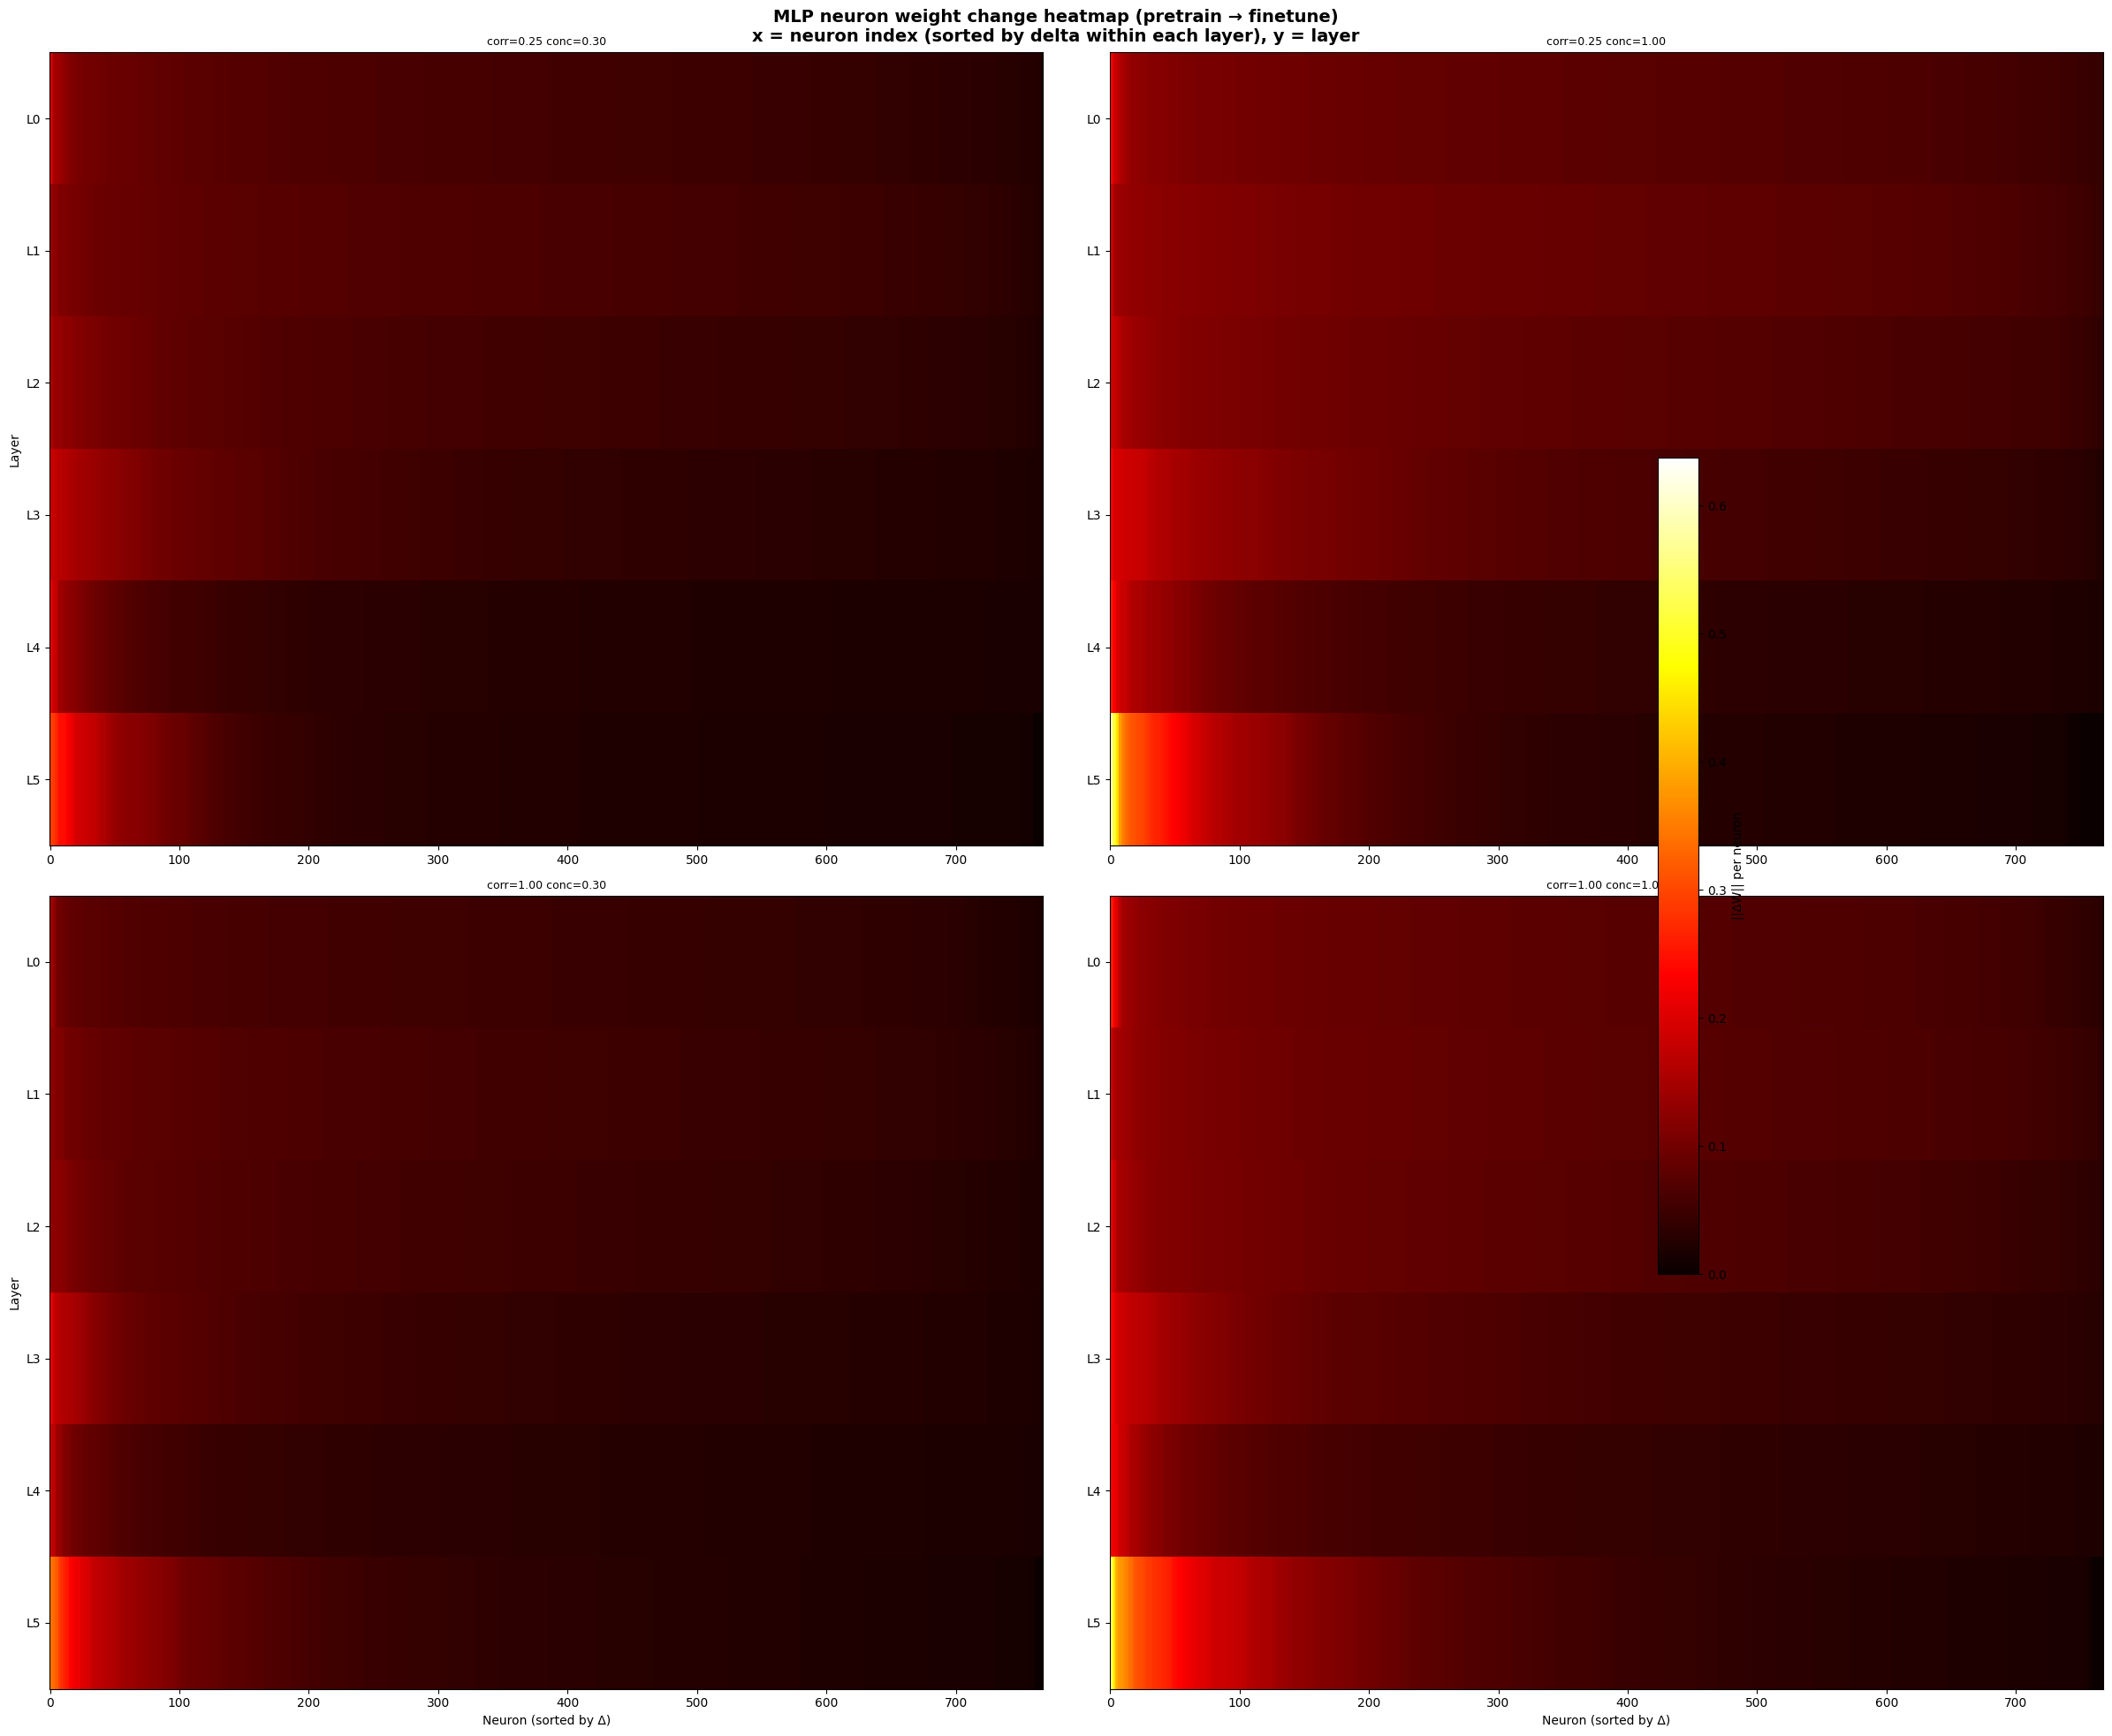

In [97]:
# Weight change per MLP neuron: pretrain → finetune

PRETRAIN_DIR = '/workspace/PCFG'
MODELS_DIR   = '/workspace/PCFG/results/models'
N_LAYERS  = mcfg['n_layer']   # 6
N_NEURONS = 4 * mcfg['n_embd']  # 768

def load_state(path):
    return torch.load(path, map_location='cpu')['model_state_dict']

def compute_mlp_neuron_deltas(state_a, state_b):
    out = np.zeros((N_LAYERS, N_NEURONS))
    for l in range(N_LAYERS):
        fc_key   = f'transformer.h.{l}.mlp.c_fc.weight'
        proj_key = f'transformer.h.{l}.mlp.c_proj.weight'
        d_fc   = (state_b[fc_key]   - state_a[fc_key]).float()
        d_proj = (state_b[proj_key] - state_a[proj_key]).float()
        out[l] = d_fc.norm(dim=1).numpy() + d_proj.norm(dim=0).numpy()
    return out

# --- Grouped bar chart: one group per model, one bar per layer ---
models = []
layer_totals_all = []
model_labels = []

for corr in CORRS:
    pretrain_path = f'{PRETRAIN_DIR}/pretrain_corr_{corr:.2f}.pth'
    if not os.path.exists(pretrain_path):
        continue
    sa = load_state(pretrain_path)
    for conc in CONCS:
        ft_path = f'{MODELS_DIR}/finetune_corr_{corr:.2f}_conc_{conc:.2f}.pth'
        if not os.path.exists(ft_path):
            continue
        sb = load_state(ft_path)
        deltas = compute_mlp_neuron_deltas(sa, sb)
        layer_totals_all.append(deltas.sum(axis=1))  # (N_LAYERS,)
        model_labels.append(f'c{corr:.0%}\nn{conc:.0%}')

n_models = len(model_labels)
x = np.arange(n_models)
bar_width = 0.8 / N_LAYERS
layer_colors = plt.cm.viridis(np.linspace(0.15, 0.85, N_LAYERS))

fig, ax = plt.subplots(figsize=(max(20, n_models * 0.8), 5))
for l in range(N_LAYERS):
    vals = [lt[l] for lt in layer_totals_all]
    offset = (l - N_LAYERS / 2 + 0.5) * bar_width
    ax.bar(x + offset, vals, bar_width, label=f'Layer {l}', color=layer_colors[l])

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=7)
ax.set_xlabel('Model (corr / conc)')
ax.set_ylabel('Total weight change per layer')
ax.set_title('MLP weight change by layer (pretrain → finetune)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=N_LAYERS)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# --- Heatmap: neuron index (x) × layer (y) ---
fig, axes = plt.subplots(len(CORRS), len(CONCS), figsize=(24, 20))
fig.suptitle('MLP neuron weight change heatmap (pretrain → finetune)\n'
             'x = neuron index (sorted by delta within each layer), y = layer',
             fontsize=14, fontweight='bold')

vmax_global = 0
all_deltas = {}
for corr in CORRS:
    pretrain_path = f'{PRETRAIN_DIR}/pretrain_corr_{corr:.2f}.pth'
    if not os.path.exists(pretrain_path):
        continue
    sa = load_state(pretrain_path)
    for conc in CONCS:
        ft_path = f'{MODELS_DIR}/finetune_corr_{corr:.2f}_conc_{conc:.2f}.pth'
        if not os.path.exists(ft_path):
            continue
        sb = load_state(ft_path)
        d = compute_mlp_neuron_deltas(sa, sb)
        all_deltas[(corr, conc)] = d
        vmax_global = max(vmax_global, d.max())

for row, corr in enumerate(CORRS):
    for col, conc in enumerate(CONCS):
        ax = axes[row, col]
        if (corr, conc) not in all_deltas:
            ax.set_visible(False)
            continue
        d = all_deltas[(corr, conc)]
        d_sorted = np.sort(d, axis=1)[:, ::-1]
        im = ax.imshow(d_sorted, aspect='auto', cmap='hot', vmin=0, vmax=vmax_global,
                       interpolation='nearest')
        ax.set_title(f'corr={corr:.2f} conc={conc:.2f}', fontsize=9)
        ax.set_yticks(range(N_LAYERS))
        ax.set_yticklabels([f'L{l}' for l in range(N_LAYERS)])
        if row == len(CORRS) - 1:
            ax.set_xlabel('Neuron (sorted by Δ)')
        if col == 0:
            ax.set_ylabel('Layer')

fig.colorbar(im, ax=axes, shrink=0.6, label='||ΔW|| per neuron')
plt.tight_layout()
plt.show()


## Gradient projection analysis

For each finetuned model, compute per-layer gradient interactions between task pairs.
Uses corr-weighted data mix matching what the model was trained on.

- **Dot product** `∇L_A · ∇L_B`: positive = cooperative, negative = competing
- **Cosine similarity**: alignment independent of magnitude
- **Gradient norms**: signal strength per task

In [98]:
def get_per_layer_grads(model, loaders_with_weights, device):
    """
    Forward+backward through weighted loaders, return per-layer gradient vectors.
    Returns dict: layer_idx -> flattened gradient tensor (on CPU).
    """
    model.train()
    model.zero_grad()

    for loader, w in loaders_with_weights:
        if w == 0:
            continue
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            logits, loss = model(input_ids, target_ids)
            (loss * w).backward()

    grads = {}
    n_layers = mcfg['n_layer']
    for l in range(n_layers):
        layer_grads = []
        for name, param in model.named_parameters():
            if f'h.{l}.' in name and param.grad is not None:
                layer_grads.append(param.grad.detach().cpu().flatten())
        if layer_grads:
            grads[l] = torch.cat(layer_grads)

    model.zero_grad()
    return grads


def compute_gradient_projection(model, task_a_loaders, task_b_loaders, device):
    """
    Compute per-layer gradient interaction between two tasks.
    task_a_loaders, task_b_loaders: list of (loader, weight) tuples.
    Returns dict with per-layer: dot_product, cosine_sim, norm_a, norm_b.
    """
    grads_a = get_per_layer_grads(model, task_a_loaders, device)
    grads_b = get_per_layer_grads(model, task_b_loaders, device)

    results = {}
    for l in grads_a:
        if l not in grads_b:
            continue
        ga, gb = grads_a[l].float(), grads_b[l].float()
        norm_a = ga.norm().item()
        norm_b = gb.norm().item()
        dot = (ga * gb).sum().item()
        cos = dot / (norm_a * norm_b + 1e-12)
        results[l] = {
            'dot_product': dot,
            'cosine_sim': cos,
            'norm_a': norm_a,
            'norm_b': norm_b,
        }
    return results


# ---- Run gradient projection for all models ----
# Task pairs to analyze:
#   count_a vs count_b  (finetune task vs pretrain task — main interaction of interest)
#   count_a vs all_other (does finetuning on count_a interfere with other tasks?)

TASK_PAIRS = [
    ('count_a', 'count_b'),
    ('count_a', 'all_other'),
]

# Map task names to their corr/uncorr loader keys
TASK_LOADER_KEYS = {
    'count_a':   ('count_a_corr',   'count_a_uncorr'),
    'count_b':   ('count_b_corr',   'count_b_uncorr'),
    'all_other': ('all_other_corr', 'all_other_uncorr'),
}

grad_proj_results = {}  # (corr, conc) -> {(task_a, task_b): per_layer_results}

for corr in CORRS:
    for conc in CONCS:
        pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
        ft_path = f'{MODELS_DIR}/finetune_{pair_name}.pth'
        if not os.path.exists(ft_path):
            continue

        print(f'\nGradient projection: {pair_name}')
        ft_state = load_state(ft_path)
        model = GPT(gpt_config).to(device)
        model.load_state_dict(ft_state)

        grad_proj_results[pair_name] = {}

        for task_a, task_b in TASK_PAIRS:
            corr_key_a, uncorr_key_a = TASK_LOADER_KEYS[task_a]
            corr_key_b, uncorr_key_b = TASK_LOADER_KEYS[task_b]

            loaders_a = [(eval_loaders[corr_key_a], corr),
                         (eval_loaders[uncorr_key_a], 1 - corr)]
            loaders_b = [(eval_loaders[corr_key_b], corr),
                         (eval_loaders[uncorr_key_b], 1 - corr)]

            res = compute_gradient_projection(model, loaders_a, loaders_b, device)
            grad_proj_results[pair_name][(task_a, task_b)] = res

            layer_cos = [res[l]['cosine_sim'] for l in sorted(res)]
            layer_dot = [res[l]['dot_product'] for l in sorted(res)]
            print(f'  {task_a} vs {task_b}:')
            print(f'    cos_sim per layer: {[f"{c:.3f}" for c in layer_cos]}')
            print(f'    dot_prod per layer: {[f"{d:.4f}" for d in layer_dot]}')

        del model

print('\nDone!')



Gradient projection: corr_0.25_conc_0.30
number of parameters: 2.82M
  count_a vs count_b:
    cos_sim per layer: ['0.410', '0.282', '0.020', '-0.040', '-0.074', '0.057']
    dot_prod per layer: ['0.0122', '0.0147', '0.0007', '-0.0028', '-0.0016', '0.0010']
  count_a vs all_other:
    cos_sim per layer: ['-0.518', '-0.591', '-0.297', '-0.228', '0.012', '-0.086']
    dot_prod per layer: ['-0.1768', '-0.4808', '-0.1456', '-0.1999', '0.0031', '-0.0248']

Gradient projection: corr_0.25_conc_1.00
number of parameters: 2.82M
  count_a vs count_b:
    cos_sim per layer: ['0.609', '0.701', '0.529', '0.520', '-0.010', '0.073']
    dot_prod per layer: ['0.1545', '0.4969', '0.2041', '0.3686', '-0.0013', '0.0081']
  count_a vs all_other:
    cos_sim per layer: ['0.663', '0.758', '0.507', '0.582', '0.292', '0.154']
    dot_prod per layer: ['3.3085', '10.8435', '2.6514', '6.1764', '0.6728', '0.4185']

Gradient projection: corr_1.00_conc_0.30
number of parameters: 2.82M
  count_a vs count_b:
    cos

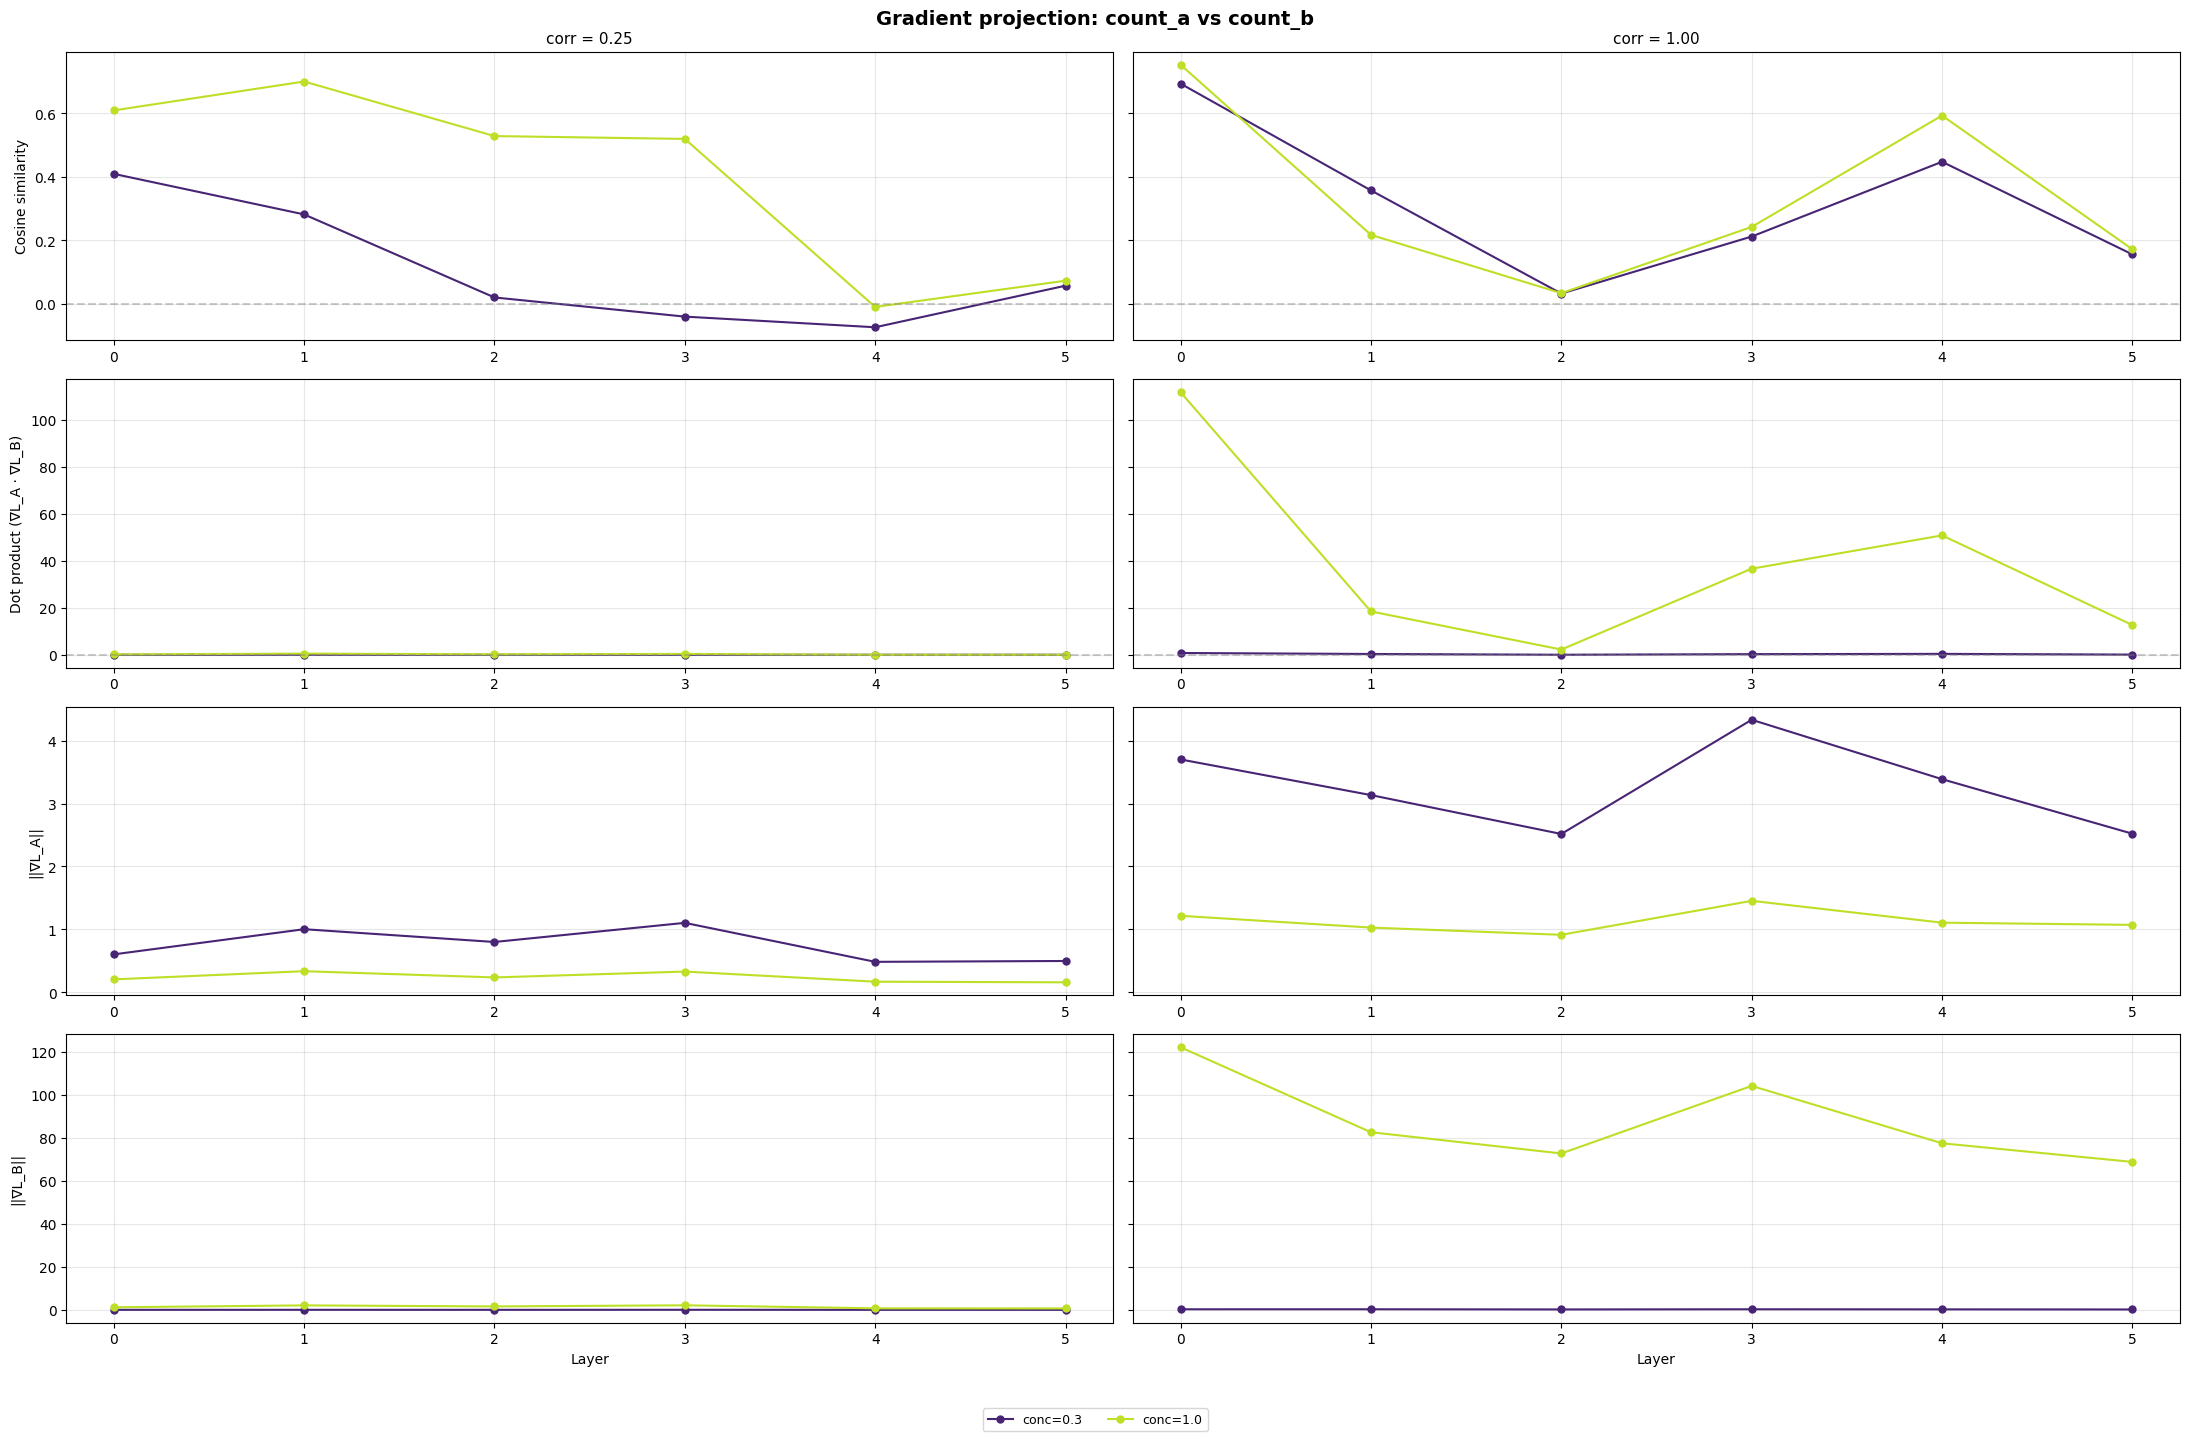

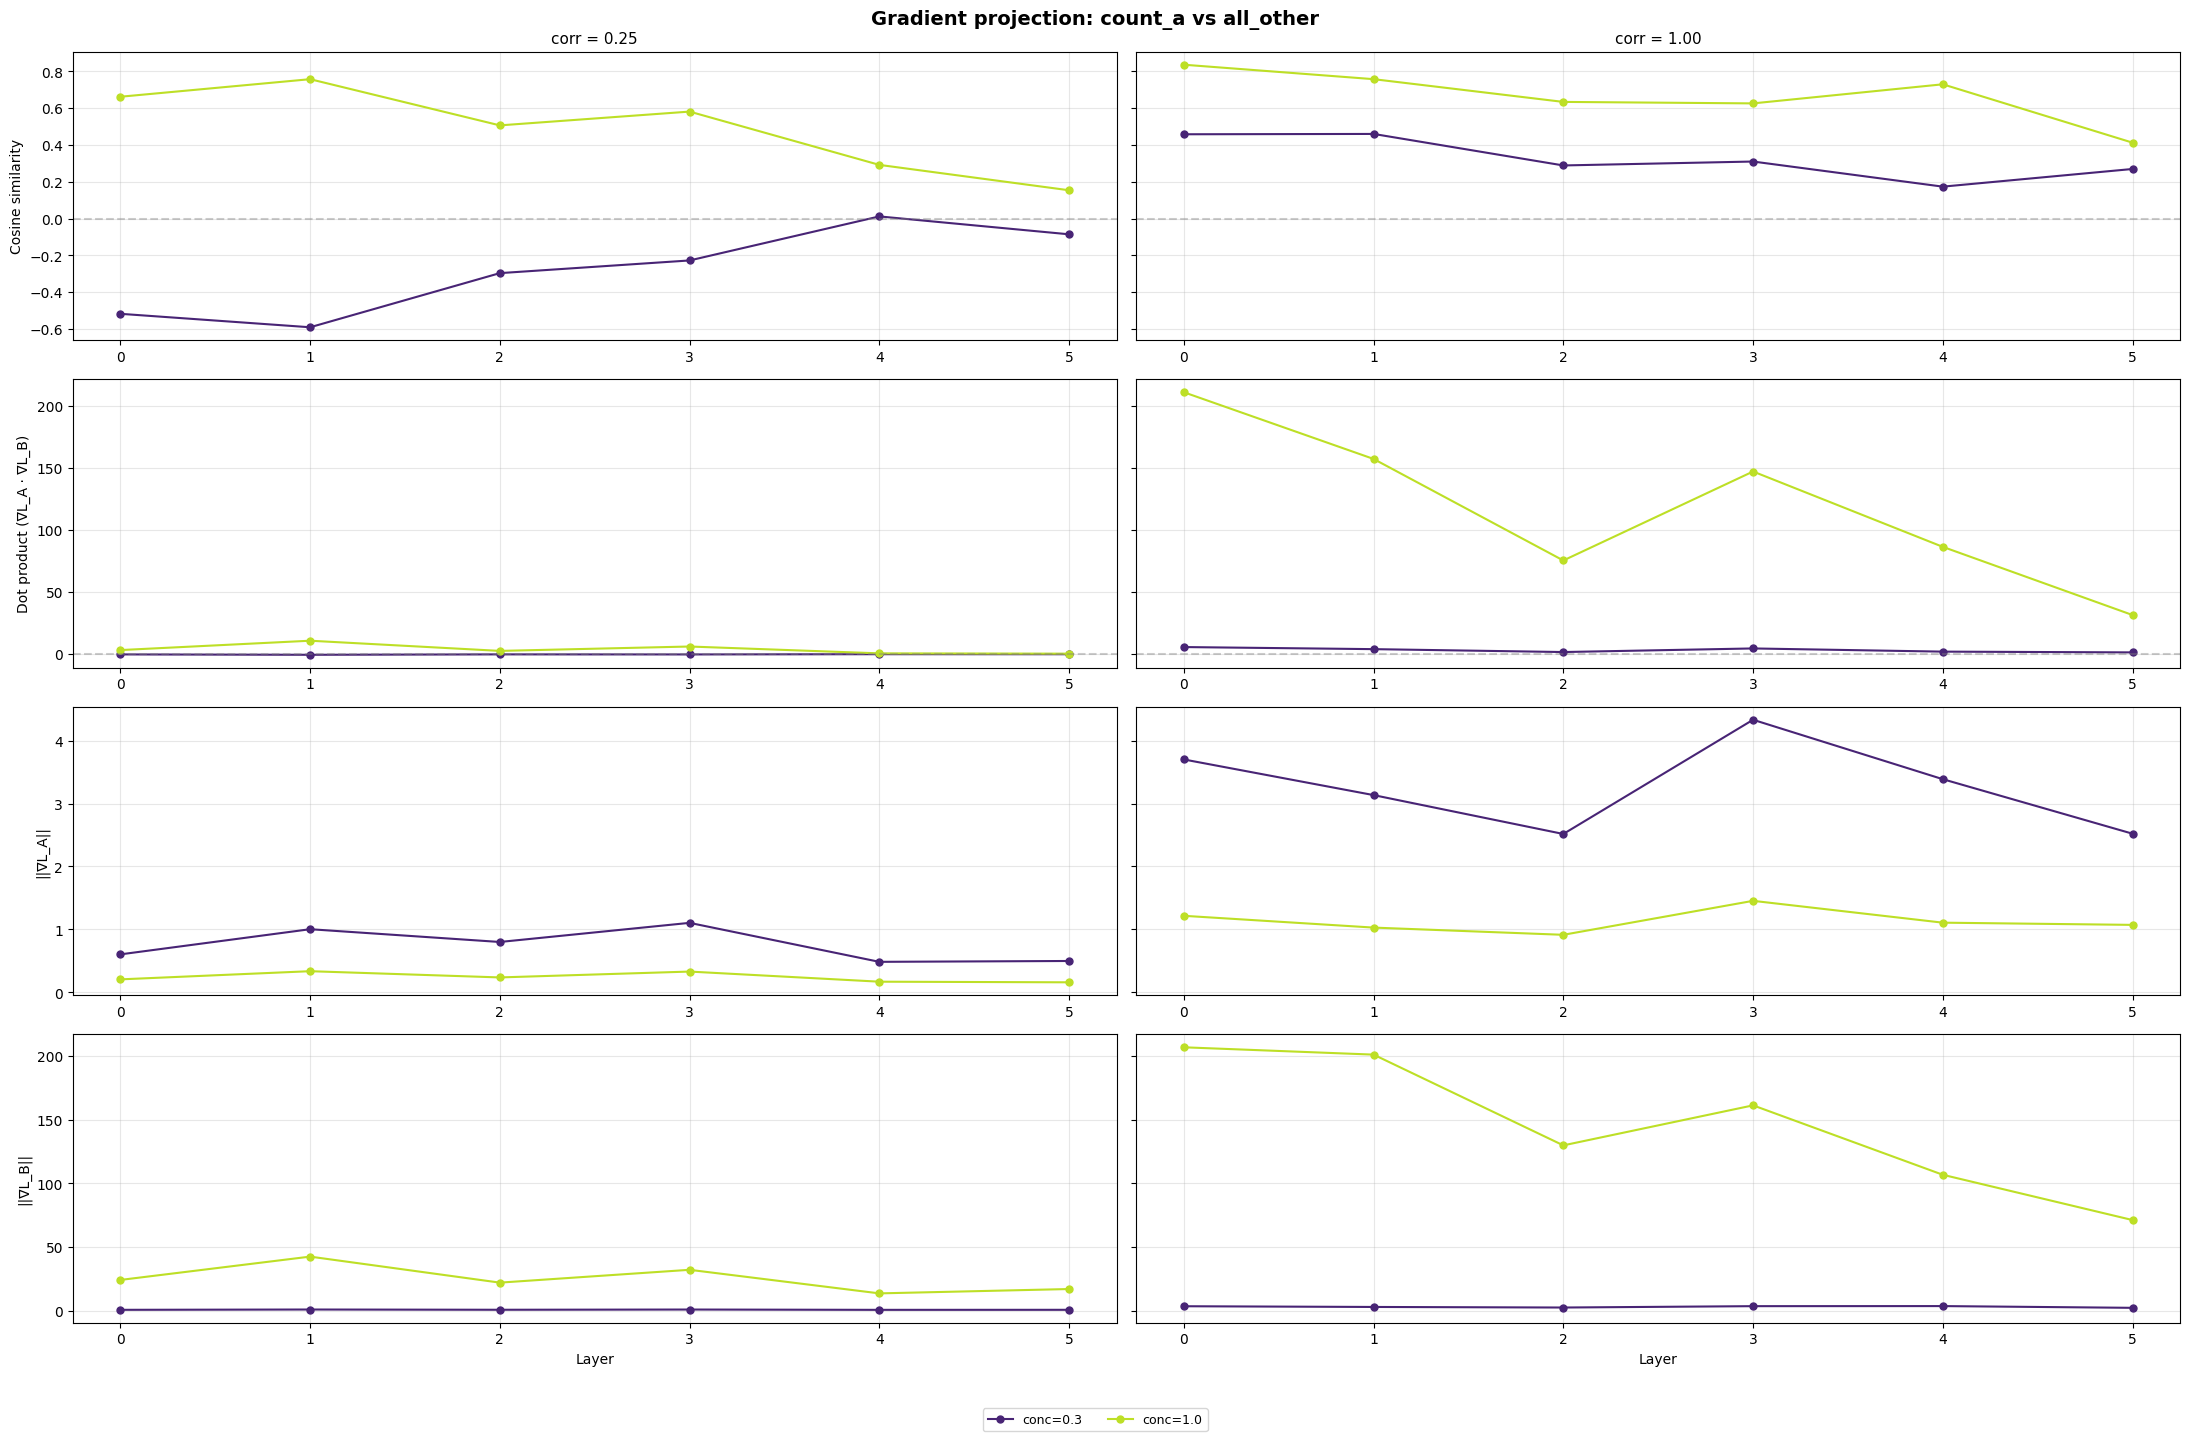

In [99]:
# Plot gradient projection results

metrics_to_plot = ['cosine_sim', 'dot_product', 'norm_a', 'norm_b']
metric_labels = {
    'cosine_sim': 'Cosine similarity',
    'dot_product': 'Dot product (∇L_A · ∇L_B)',
    'norm_a': '||∇L_A||',
    'norm_b': '||∇L_B||',
}

CONC_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONCS)))
n_layers = mcfg['n_layer']

for task_a, task_b in TASK_PAIRS:
    fig, axes = plt.subplots(len(metrics_to_plot), len(CORRS),
                             figsize=(22, 14), sharey='row')
    fig.suptitle(f'Gradient projection: {task_a} vs {task_b}',
                 fontsize=14, fontweight='bold')

    for row, metric in enumerate(metrics_to_plot):
        for col, corr in enumerate(CORRS):
            ax = axes[row, col]
            for conc, color in zip(CONCS, CONC_COLORS):
                pair_name = f'corr_{corr:.2f}_conc_{conc:.2f}'
                if pair_name not in grad_proj_results:
                    continue
                res = grad_proj_results[pair_name].get((task_a, task_b))
                if res is None:
                    continue
                layers = sorted(res.keys())
                vals = [res[l][metric] for l in layers]
                ax.plot(layers, vals, 'o-', color=color, linewidth=1.5,
                        markersize=5, label=f'conc={conc:.1f}')

            if metric == 'cosine_sim':
                ax.axhline(0, color='grey', linestyle='--', alpha=0.4)
            if metric == 'dot_product':
                ax.axhline(0, color='grey', linestyle='--', alpha=0.4)
            ax.set_xticks(range(n_layers))
            ax.grid(True, alpha=0.3)
            if row == 0:
                ax.set_title(f'corr = {corr:.2f}', fontsize=11)
            if row == len(metrics_to_plot) - 1:
                ax.set_xlabel('Layer')
            if col == 0:
                ax.set_ylabel(metric_labels[metric])

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(CONCS),
               fontsize=9, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()
